<br>

# __PROJET DE MACHINE LEARNING__ 

<br><br>

__Informations générales__ : 

__Groupe__ : ZAHNI Ryan,
            KAGAN Anaïs

__Titre__ : Analyse comparative d'une méthode des moindres carrés ordinaires et de méthodes de régularisation (Ridge,LASSO) pour la prédiction de la valeur d'un bien immobilier et la détérmination des facteurs qui influcent le plus les prix.

__Problématique__ : Dans quelle mesure l'ajout d'une pénalité de régularisation (Ridge,LASSO) permet-elle d'améliorer la méthode des moindres carrés ?
<br><br><br><br>

### __I.  INTRODUCTION__ 
<br><br>

__a) Généralités__

L'objectif de ce projet est de comparer trois modèles de régression : la méthode des moindres carrés ordinaires, la régularisation Ridge, et la régularisation LASSO. Pour cela, nous avons choisi de modéliser la valeur des biens immobiliers à partir d'un jeu de données "House Prices" disponible sur le site de Kaggle à l'adresse suivante : https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data
    
Nous savons que  la valeur d'un bien immobilier est déterminée par de nombreux facteurs, comme la surface habitable, le quartier ou encore l'année de construction du logement. Cependant, on remarque que les variables qui caractérisent le prix des logements sont très corrélées. Par exemple, nous voyons que la surface habitable d'un logement est liée avec le nombre de pièces dont il dispose. 
    
Cette corrélation entre les données, que l'on appelle aussi multicolinéarité, est un problème majeur pour de nombreux modèles, en particulier pour la méthode des moindres carrés ordinaires. En effet, la méthode des moindres carrés a tendance à sur-estimer l'importance de certains coefficients, ce qui rend difficile l'identification des facteurs qui influencent le plus les prix. La multicolinéarité pose aussi un problème d'overfitting. En effet, la méthode devient très sensible aux variations (le bruit) du jeu de données : le modèle mémorise les particularités des données d'entraînement, ce qui le rend très précis sur ces données, mais incapable de généraliser à de nouvelles maisons. En ajoutant une pénalité sur la fonction objectif, les régularisations Ridge et LASSO permettent d'améliorer le modèle en faisant diminuer l'importance des coefficients qui auraient tendance à être sur-estimés lors de la méthode des moindres carrés ordinaires.

Voici les détails de ce raisonnement : 
<br><br>

__b) Détails sur la méthode des moindres carrés ordinaires__
    
La méthode des moindres carrés ordinaires est une méthode de régréssion linéaire classique. L'objectif est de trouver le vecteur de paramètres $\theta$ qui minimise la somme des carrés des résidus, c'est-à-dire l'écart quadratique entre les prix réels $y_i$ et les prix prédits $\hat{y}_i$.

La fonction de coût C($\theta$) s'écrit : <br>
C($\theta$) = $ \sum_{i=1}^{m} (y_i - \hat{y}_i)^2$      où m est le nombre d'observations
    
La solution optimale est obtenue par l'équation normale : <br>
$\hat{\theta} = (X^T X)^{-1}X^T y$

-> Idée de la preuve : on calcule le gradiant de la fonction de coût, puis on trouve le coefficient $\theta$ qui annule le gradiant. On vérifie que ce point est bien un point de minimum car la fonction est convexe (la hessienne de la fonction de coût est semi-définie positive).
<br><br>
__Problème__ : Si les variables explicatives sont très corrélées, alors la matrice $(X^T X)$ devient difficile à inverser car son déterminant est très proche de zéro, ce qui rend son inversion numériquement instable. En effet, lors des calculs, l'ordinateur doit manipuler des nombres très petits. Le problème est que les erreurs d'arrondi s'accumulent au fil des calculs. A cause de cela, un changement même infime de nos données peut entraîner un changement colossal dans nos résultats pour $\theta$. Cette instabilité provoque une explosion de la variance des coefficients $\theta$ conduisant au phénomène d'overfitting évoqué plus haut. 
<br><br>

__c) La solution : La régularisation Ridge__

__RIDGE__

Plutôt que de chercher à minimiser l'erreur quadratique, la régularisation Ridge intégère une pénalité à sa fonction de coût :<br>
C($\theta$) = $\sum_{i=1}^{m} (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{n}\theta_j^2$ où m est le nombre d'observations (les lignes) et n est le nombre de variables (les colonnes)<br>

Matriciellement, cela revient à ajouter un terme $\lambda$ sur la diagonale de la matrice avant l'inversion : <br>
$\hat{\theta}_{Ridge} = (X^T X + \lambda I)^{-1} X^T y$

Si $\lambda = 0$, on retombe sur une méthode des moindres carrés.<br>
Si $\lambda > 0$, le déterminant ne sera plus proche de 0 car la matrice $X^TX$ devient définie positive. Cela impose une contrainte sur la norme des paramètres $\theta$ : le modèle ne peut plus attribuer des poids trop importants à des variables corrélées. La variance des coefficients $\theta$ diminue alors fortement, ce qui résout le problème d'overfitting. On perd légèrement en précisions (biais) sur les données d'entraînement mais on en gagne sur les données de test.

__LASSO__

De la même manière, la régularisation LASSO intègre elle aussi une pénalité à sa fonction :
C($\theta$) = $\sum_{i=1}^{m} (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{n}|\theta_j|$ <br>

Cette méthode est idéale pour simplifier le modèle car elle impose une contrainte sur la norme des coeffients $\theta$, qui peuvent aussi devenir nuls (contrairement à la régularisation Ridge où les coefficients ne deviennent jamais nuls). On peut alors mieux gérer les problèmes liés à la multicolinéarité mais aussi simplifier le modèle en accordant des coefficients nuls aux variables peu pertinentes. 
<br><br>

__Cross validation__

On voit ici toute l'importance de choisir le bon coefficient $\lambda$. Pour cela, on utilise généralement la cross validation. L'une des méthodes les plus courantes est la K-Fold Cross-Validation. Voici comment cela fonctionne : 
1. Diviser les données en K groupes ("folds").
2. Pour chaque pli k=1,...,K : 
    Utiliser le pli k comme ensemble de validation (pour tester le $\lambda$) et les K-1 plis restants comme ensemble d'entraînement (pour calculer les $\theta$) et prédire la variable de réponse pour l'ensemble de validation.
    Calculer une métrique de performance (par exemple l'erreur quadratique moyenne) pour chaque valeur lambda de l'ensemble de validation.
3. Pour chaque valeur lambda, moyenner la métrique de performance sur tous les K folds.
4. Sélectionner le lambda optimal, ie celui qui minimise l'erreur moyenne.

<br><br><br>

__Références :__

https://fr.statisticseasily.com/glossaire/qu%27est-ce-que-les-vieux-moindres-carr%C3%A9s-ordinaires/ <br>
https://app.studyraid.com/fr/read/22590/912001/methode-des-moindres-carres-ordinaires <br>
https://www.statisticalaid.com/ridge-regression/

<br><br><br>
### __II. Nettoyage du dataset__


__a) Préparation des données__

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy category_encoders

In [2]:
import pandas as pd 

df=pd.read_csv('train.csv',sep=';') #importer le dataset téléchargé depuis Kaggle

In [3]:
# Suppression des colonnes qui ne nous aideront pas pour prédire notre SalePrice
# On a fait une première sélection basée sur la logique :
# - colonnes avec beaucoup de valeurs manquantes
# - colonnes quasi constantes
# - colonnes redondantes avec d'autres plus informatives

cols_a_supprimer = [
    'Id',             # identifiant, pas utile pour la prédiction (nous ajoute aucune information sur la maison)
    'Alley',          # trop de valeurs manquantes
    'Fence',          # idem
    'PoolQC',         # 99% NaN
    'FireplaceQu',    # trop de NA
    'Utilities',      # toutes maisons ont l'électricité → pas d'infos
    'Condition2',     # presque jamais utilisé
    'RoofMatl',       # matériau de toit très similaire pour toutes
    'Heating',        # type de chauffage, redondant avec HeatingQC
    'LowQualFinSF',   # surface de finition basse qualité quasi toujours 0
    '3SsnPorch',      # très peu de maisons ont ça
    'MiscFeature',    # beaucoup de NA et peu utile
    'MiscVal',        # souvent 0, pas informatif
    'Street',         # presque toutes pavées, pas de variance
    'LandSlope',      # peu de maisons ont une pente extrême
    'LotConfig',      # redondant avec LotShape et Surface du terrain
    'RoofStyle',      # pas très discriminant pour le prix
    'Exterior2nd',    # souvent identique à Exterior1st
    'BsmtFinType2',   # second sous-sol fini, rare
    'BsmtFinSF2',     # surface associée quasi toujours 0
    'BsmtHalfBath',   # peu d'impact
    'PoolArea',       # très peu de piscines
    'GarageYrBlt',    # couvert par YearBuilt et GarageFinish
    'MoSold',         # mois de vente, faible impact
]

# On supprime toutes ces colonnes du dataframe
df = df.drop(columns=cols_a_supprimer)



In [4]:
# On renomme certaines colonnes pour qu'elles soient plus compréhensibles en français
# Cela rend l'analyse plus claire et facilite la lecture du dataset 

df.rename(columns={
    'MSZoning': 'Zonage',                 
    'LotArea': 'Surface du terrain',      # exprimée en pieds carrés: ft**2      
    'LotShape': 'Forme du terrain',                         
    'TotRmsAbvGrd':'Nombre total de pièces', 
    'OverallQual': 'Qualité globale',    
    'OverallCond': 'Condition globale',   
    'YearBuilt': 'Année construction',    
    'YearRemodAdd': 'Année rénovation',   
    'GrLivArea': 'Surface habitable',     
    'TotalBsmtSF': 'Surface sous-sol',    
    'GarageCars': 'Places garage',       
    'Fireplaces': 'Nombre cheminées',     
    'KitchenQual': 'Qualité cuisine',     
    'ExterQual': 'Qualité extérieure',    
    'HeatingQC': 'Qualité chauffage',      
    '2ndFlrSF':'Surface du deuxième étage',
    'GarageArea': 'Surface garage',       
    'BedroomAbvGr':'Nombre de chambre aux étages',
    'YrSold': 'Année de vente'
}, inplace=True)


__b) Transformation des données textuelles en données numériques__

Nous décomposons nos variables ainsi :
- Les variables ordinales (avec un ordre logique, ex : Qualité) sont converties en chiffres selon leur échelle.<br>
- Les variables nominales (sans ordre, ex : Zonage) sont encodées en "One-Hot" pour éviter d'introduire une hiérarchie.
- Target Encoding : Pour les variables ayant trop de catégories (ex: Quartier), où le One-Hot Encoding alourdirait trop le modèle.
  Le principe étant qu'on remplace chaque catégorie par la moyenne des prix constatée pour cette catégorie dans le set d'entraînement.
  Cela transforme un texte complexe en un indicateur numérique direct, montrant immédiatement l'influence de chaque catégorie sur le prix final
  sans   multiplier le nombre de colonnes.


In [5]:
txt_colonnes = df.select_dtypes(include=['object', 'string']).columns

In [6]:
# première erreur réalisée : on a assigné des valeurs numériques à 'Zonage' sans vérifier que c'était une variable ordinale (ce qui n'était pas le cas).
# Heureusement, cela n'a pas causé de problème majeur pour notre modèle, mais c'est une bonne pratique de vérifier la nature des variables avant de les encoder.
# On s est rendu compte que 'Zonage' est une variable nominale (pas d'ordre entre les catégories), donc l'encodage numérique direct n'était pas idéal.
# pour remédier à cela, on aurait pu faire du one-hot encoding pour 'Zonage' afin de créer des colonnes séparées pour chaque catégorie, ce qui aurait été plus approprié pour une variable nominale.
# ainsi on a rectifié en faisant du one-hot encoding pour 'Zonage' après avoir réalisé que c'était une variable nominale, ce qui a amélioré les performances de notre modèle.
# en effet notre modèle risque de prendre en compte les valeurs numériques de 'Zonage' comme s'il y avait un ordre entre les catégories, ce qui n'est pas le cas, et cela peut biaiser les prédictions. (exemple : il pourrait penser que 'RM' (1) est mieux que 'RL' (0) ou que 'C (all)' (2) est mieux que 'RM' (1), alors qu'en réalité ce n'est pas le cas, ce sont juste des catégories différentes sans ordre intrinsèque).)


#replacement_dict = {
#    'RL':0,
#    'RM':1,
#    'C':2,
#    'FV':3,}

# df['Zonage'] = df['Zonage'].replace(replacement_dict)
# print (df.head())

# voici la correction que nous avons apportée pour 'Zonage' :
df = pd.get_dummies(df, columns=['Zonage'])

# on fait ca pour le de reste des variables nominales à basse cardinalité (moins de 10 catégories) pour éviter de créer trop de colonnes et de rendre le modèle plus complexe qu'il ne le faut.
# 1. On crée la liste exacte des variables à basse cardinalité
cols_one_hot = [
    'CentralAir',
    'Forme du terrain',
    'LandContour',
    'BldgType',
    'MasVnrType',
    'Foundation',
    'GarageType',
    'PavedDrive',
    'SaleCondition'
]

# 2. On applique l'encodage sur le dataframe
# Le drop_first=True est crucial pour éviter la redondance d'informations
df = pd.get_dummies(df, columns=cols_one_hot, drop_first=True)

# 3. On vérifie
print(f"Nouvelles dimensions du dataset : {df.shape}")
print("Aperçu des nouvelles colonnes créées :")
print(df.head())

#on remarque que le nombre de colonnes a considérablement augmenté après l'encodage, ce qui est normal car chaque catégorie de chaque variable nominale a été transformée en une colonne binaire (0 ou 1).
#Comme on a été très stratégiques et qu'on a sélectionné uniquement des variables avec très peu de choix, les dégâts sont hyper limités (surtout grâce au drop_first=True qui économise une colonne à chaque fois).Par exemple :CentralAir (2 choix) $\rightarrow$ rajoute 1 dimension.PavedDrive (3 choix) $\rightarrow$ rajoute 2 dimensions.BldgType (5 choix) $\rightarrow$ rajoute 4 dimensions.Au total, pour tes 10 variables, on va rajouter environ 35 à 40 colonnes.Pourquoi ce n'est pas un problème ici ?

# on remarque que les colonnes ajoutés sont des booleens de la forme 'false' ou 'true' (0 ou 1) et que cela ne pose pas de problème pour les modèles de machine learning, au contraire, cela leur permet de mieux comprendre les différentes catégories et d'apprendre des relations plus complexes entre les variables.
# on peut aussi convertir en 0 et 1 pour que ce soit plus clair pour le modèle, mais en général les modèles de machine learning comprennent très bien les variables binaires même si elles sont sous forme de 'false' et 'true'.


Nouvelles dimensions du dataset : (1460, 78)
Aperçu des nouvelles colonnes créées :
   MSSubClass  LotFrontage  Surface du terrain Neighborhood  Qualité globale  \
0          60         65.0                8450      CollgCr                7   
1          20         80.0                9600      Veenker                6   
2          60         68.0               11250      CollgCr                7   
3          70         60.0                9550      Crawfor                7   
4          60         84.0               14260      NoRidge                8   

   Condition globale  Année construction  Année rénovation Exterior1st  \
0                  5                2003              2003     VinylSd   
1                  8                1976              1976     MetalSd   
2                  5                2001              2002     VinylSd   
3                  5                1915              1970     Wd Sdng   
4                  5                2000              2000     Vi

In [7]:

# 1. on utilise un dictionnaire classique (classement Excellent -> Médiocre)
# On associe une note numérique à chaque niveau de qualité
# Ex = Excellent, Gd = Good, TA = Typical/Average, Fa = Fair, Po = Poor
mapping_qualite = {
    'Ex': 5, 
    'Gd': 4, 
    'TA': 3, 
    'Fa': 2, 
    'Po': 1, 
    'NA': 0  # 0 si la maison n'a pas cet élément (ex: pas de garage)
}

# Liste des colonnes qui utilisent ce système de notation standard dans notre dataset
cols_qualite = [
    'Qualité extérieure',
    'Qualité chauffage', 
    'Qualité cuisine', 
    'ExterCond',
    'BsmtQual', 
    'BsmtCond', 
    'GarageQual', 
    'GarageCond',
]

# On applique le mapping sur toutes ces colonnes avec une boucle
for col in cols_qualite:
    # Le .fillna(0) sert au cas où il y a de vraies valeurs manquantes (NaN)
    df[col] = df[col].map(mapping_qualite).fillna(0).astype(int) #fillna remplace les valeurs inconnues par 0


# 2. Les mappings spécifiques
# Certaines colonnes ont un vocabulaire différent, il faut leur propre dictionnaire

# Exposition du sous-sol (Good, Average, Minimum, No)
mapping_bsmt_exposure = {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'NA': 0}
if 'BsmtExposure' in df.columns:
    df['BsmtExposure'] = df['BsmtExposure'].map(mapping_bsmt_exposure).fillna(0).astype(int)

# Qualité des finitions du sous-sol (Good Living Quarters, Average, etc.)
mapping_bsmt_fin = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'NA': 0}
if 'BsmtFinType1' in df.columns:
    df['BsmtFinType1'] = df['BsmtFinType1'].map(mapping_bsmt_fin).fillna(0).astype(int)

# Finition du garage (Finished, Rough Finished, Unfinished)
mapping_garage_finish = {'Fin': 3, 'RFn': 2, 'Unf': 1, 'NA': 0}
if 'GarageFinish' in df.columns:
    df['GarageFinish'] = df['GarageFinish'].map(mapping_garage_finish).fillna(0).astype(int)
df.head()


,MSSubClass,LotFrontage,Surface du terrain,Neighborhood,Qualité globale,Condition globale,Année construction,Année rénovation,Exterior1st,MasVnrArea,...,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,PavedDrive_P,PavedDrive_Y,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,CollgCr,7,5,2003,2003,VinylSd,196.0,...,False,False,False,False,True,False,False,False,True,False
1,20,80.0,9600,Veenker,6,8,1976,1976,MetalSd,0.0,...,False,False,False,False,True,False,False,False,True,False
2,60,68.0,11250,CollgCr,7,5,2001,2002,VinylSd,162.0,...,False,False,False,False,True,False,False,False,True,False
3,70,60.0,9550,Crawfor,7,5,1915,1970,Wd Sdng,0.0,...,False,False,True,False,True,False,False,False,False,False
4,60,84.0,14260,NoRidge,8,5,2000,2000,VinylSd,350.0,...,False,False,False,False,True,False,False,False,True,False


In [8]:
# LE TARGET ENCODING
from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split

# On définit les colonnes catégorielles à encoder
categorical_columns = ['Neighborhood', 'Exterior1st', 'SaleType']

# Rappel 
# Neighborhood : C'est le critère n°1 en immobilier. Remplacer le nom du quartier par le prix moyen du secteur donne immédiatement au modèle une information de "standing".
# Exterior1st : Certains matériaux (comme le brique vs le bois) sont statistiquement plus chers. Le Target Encoding capte cette hiérarchie de prix automatiquement.
# SaleType : Une vente neuve (New) aura une moyenne de prix bien plus élevée qu'une vente en saisie judiciaire (AdjLand). L'encodage transforme cette catégorie en un "indice de valeur".


# Séparer les variables explicatives X et la variable cible y
X = df.drop(columns='SalePrice')
y = df['SalePrice']

# On sépare les données en ensemble d'entraînement et de test
# (on conserve 20% des données pour le test)
X_training, X_testing, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# On initialise le Target Encoder
encoder = TargetEncoder(cols=categorical_columns)

# 5. Apprendre l'encodage sur le TRAIN puis transformer le TRAIN
X_train = encoder.fit_transform(X_training, y_train)

# 6. Transformer le TEST (sans réapprendre pour éviter le data leakage)
X_test = encoder.transform(X_testing)



__c) Vérification et affichage du dataset final__

In [9]:
#on peut afficher notre jeu de données netoyer après toutes ces étapes de nettoyage et d'encodage pour vérifier que tout est en ordre et que les transformations ont été appliquées correctement.

X_train.head()
X_train.shape
# Rappel: les booleens de type false et true sont bien compris par les modèles de machine learning, donc il n'est pas nécessaire de les convertir en 0 et 1.

(1168, 77)

<br><br><br><br>
### __III. Mise en évidence des liens de corrélation sur notre jeu de données__ <br><br><br>

__a) Affichage de la heatmap__

Une heatmap est une représentation graphique de la matrice de corrélation des données qui repose sur le principe d'un nuancier de couleurs.<br>
Chaque case de la matrice est l'intersection de deux variables.<br> 
Plus la valeur d'une case est proche de 1, plus les variables en ligne et en colonne sont corrélées positivement (si une des variables en ligne ou en colonne augmente, l'autre aussi).<br>
A l'inverse, plus la valeur d'une case est proche de -1, plus les variables sont corrélées négativement (si l'une diminue, l'autre augmente).<br>
Une valeur proche de 0 signifie l'absence de corrélation entre les deux variabes.

Généralement, le code couleur est le suivant : 
- Plus la couleur est chaude (rouge), plus la corrélation est forte (corrélation positive)
- Plus la couleur est blanche, plus la corrélation est faible
- Plus la couleur est froide (bleu), plus la corrélation est forte (corrélation négative)

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


<Axes: >

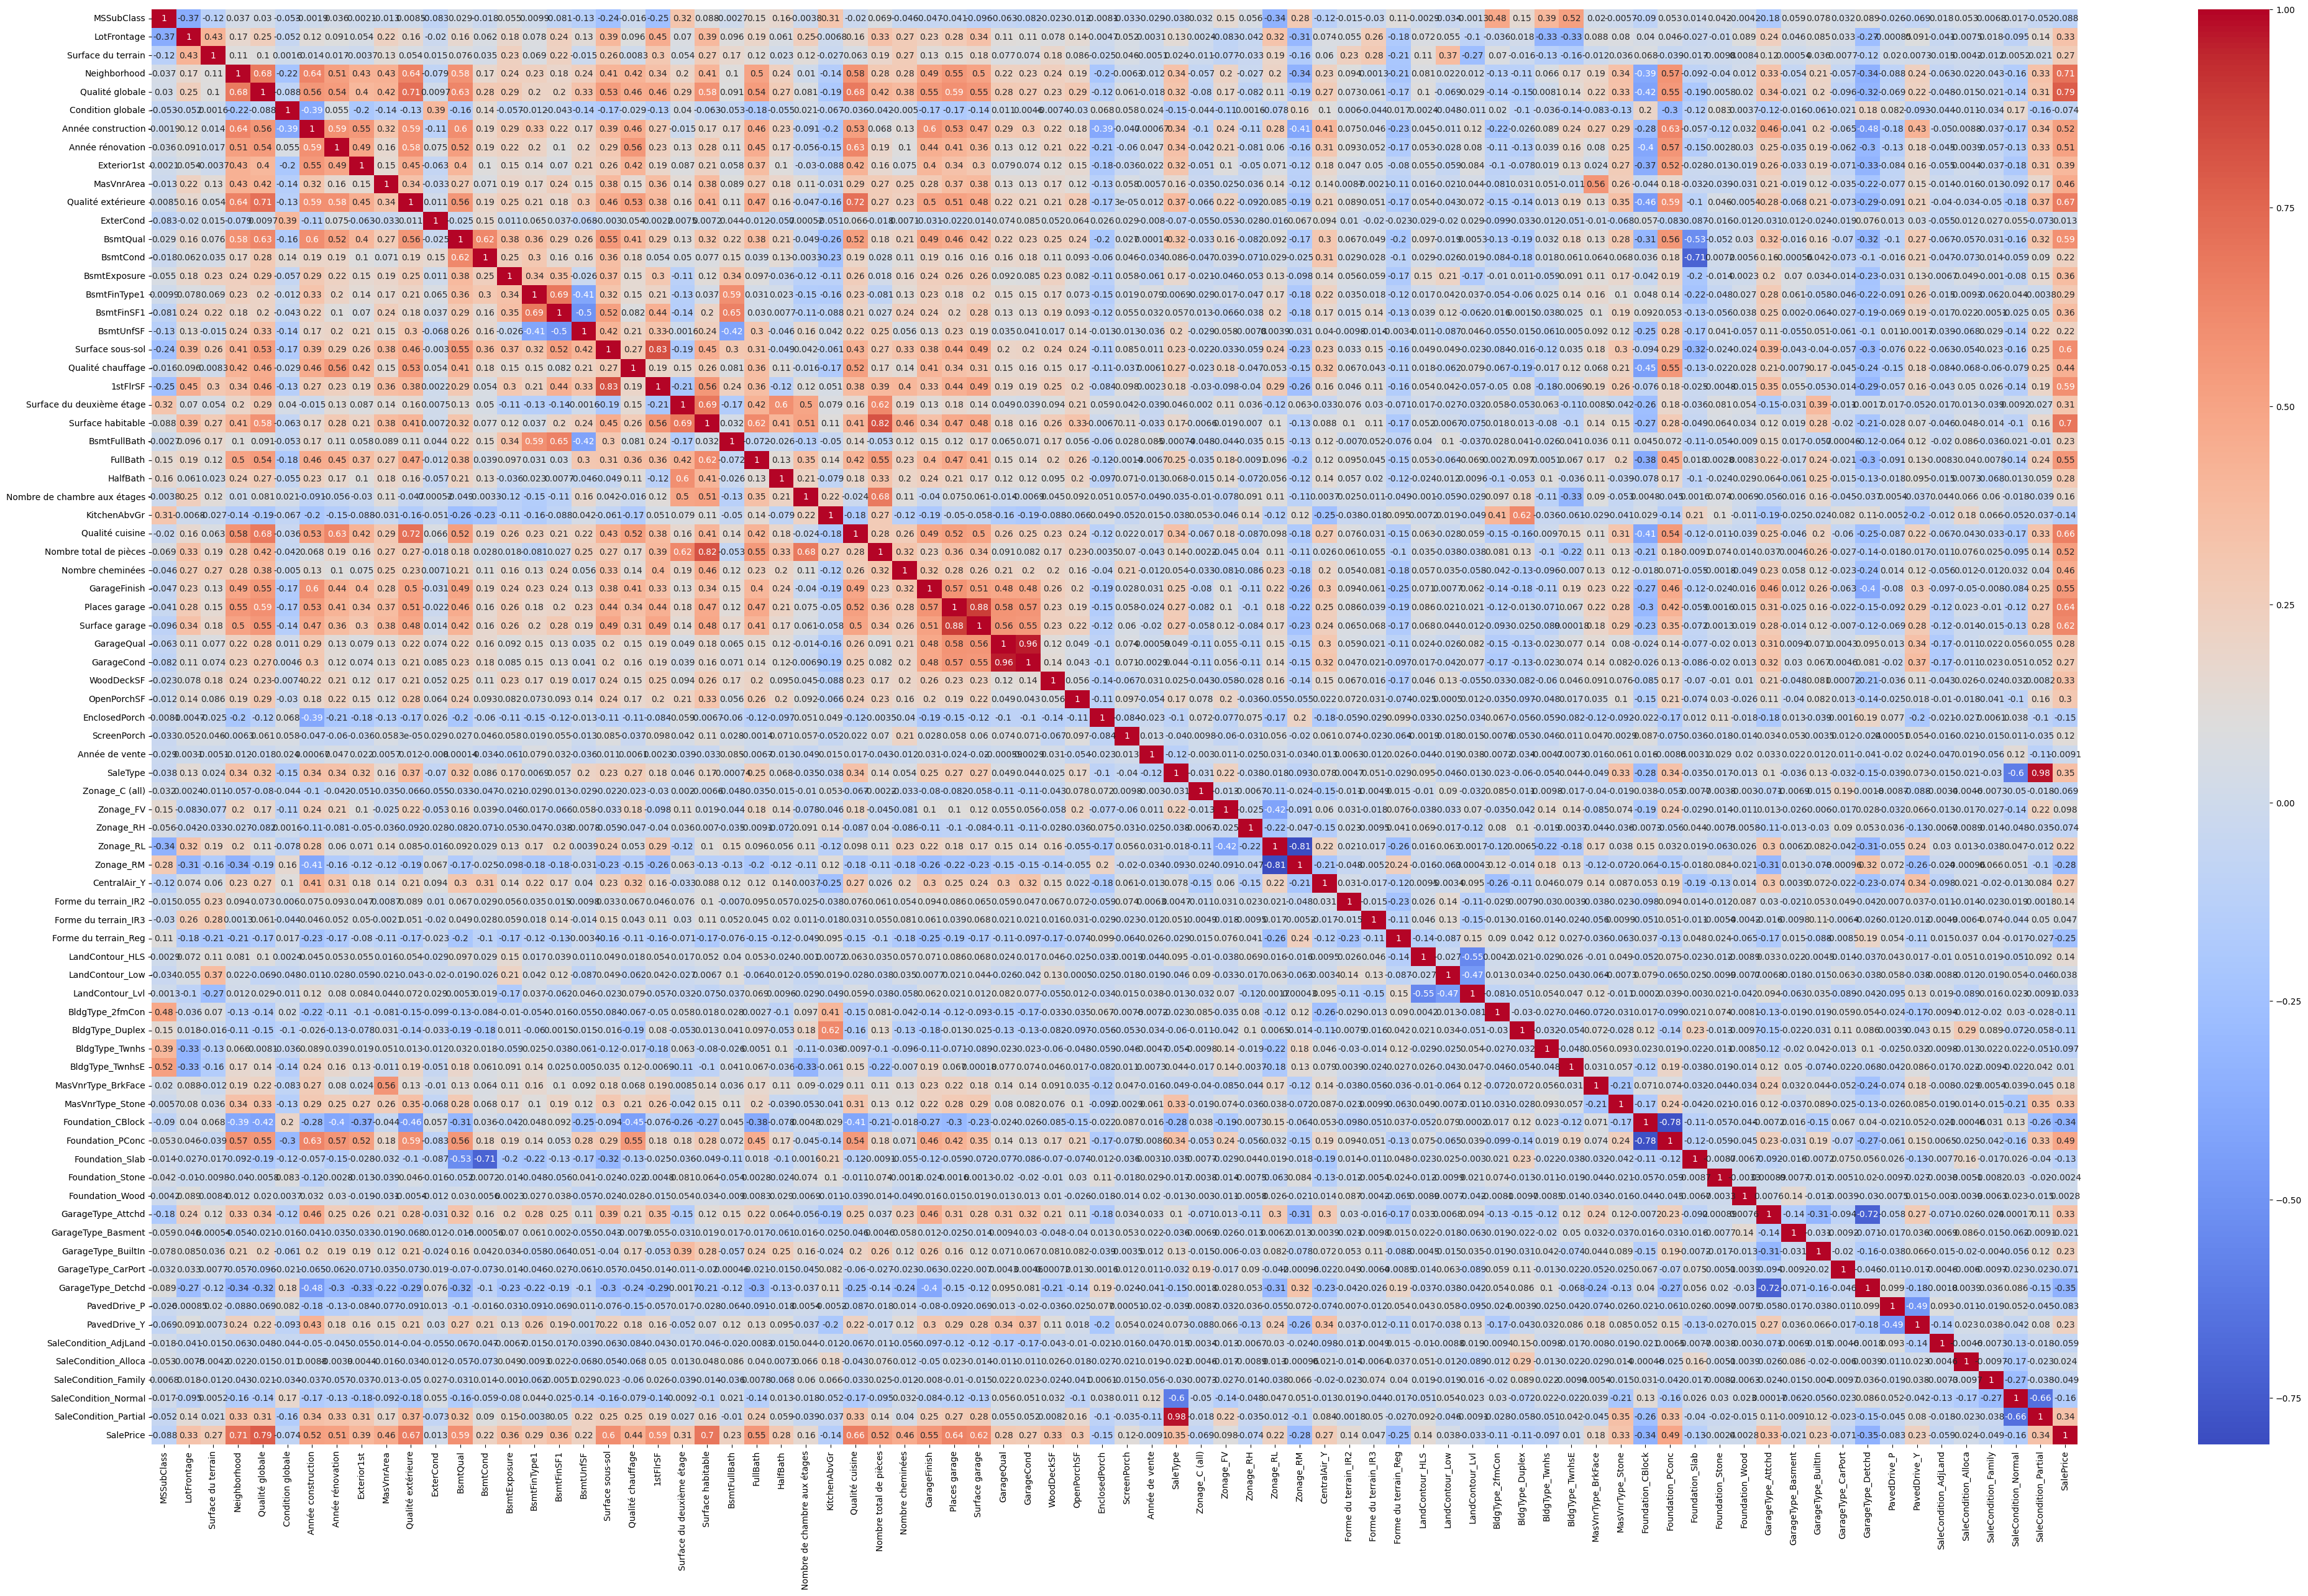

In [11]:
plt.figure(figsize=(50, 30))
sns.heatmap(pd.concat([X_train,y_train],axis=1).corr(), annot=True,cmap="coolwarm")

Pour plus de lisibilité, faisons un zoom sur quelques variables qui pourraient nous intéresser : 



<Axes: >

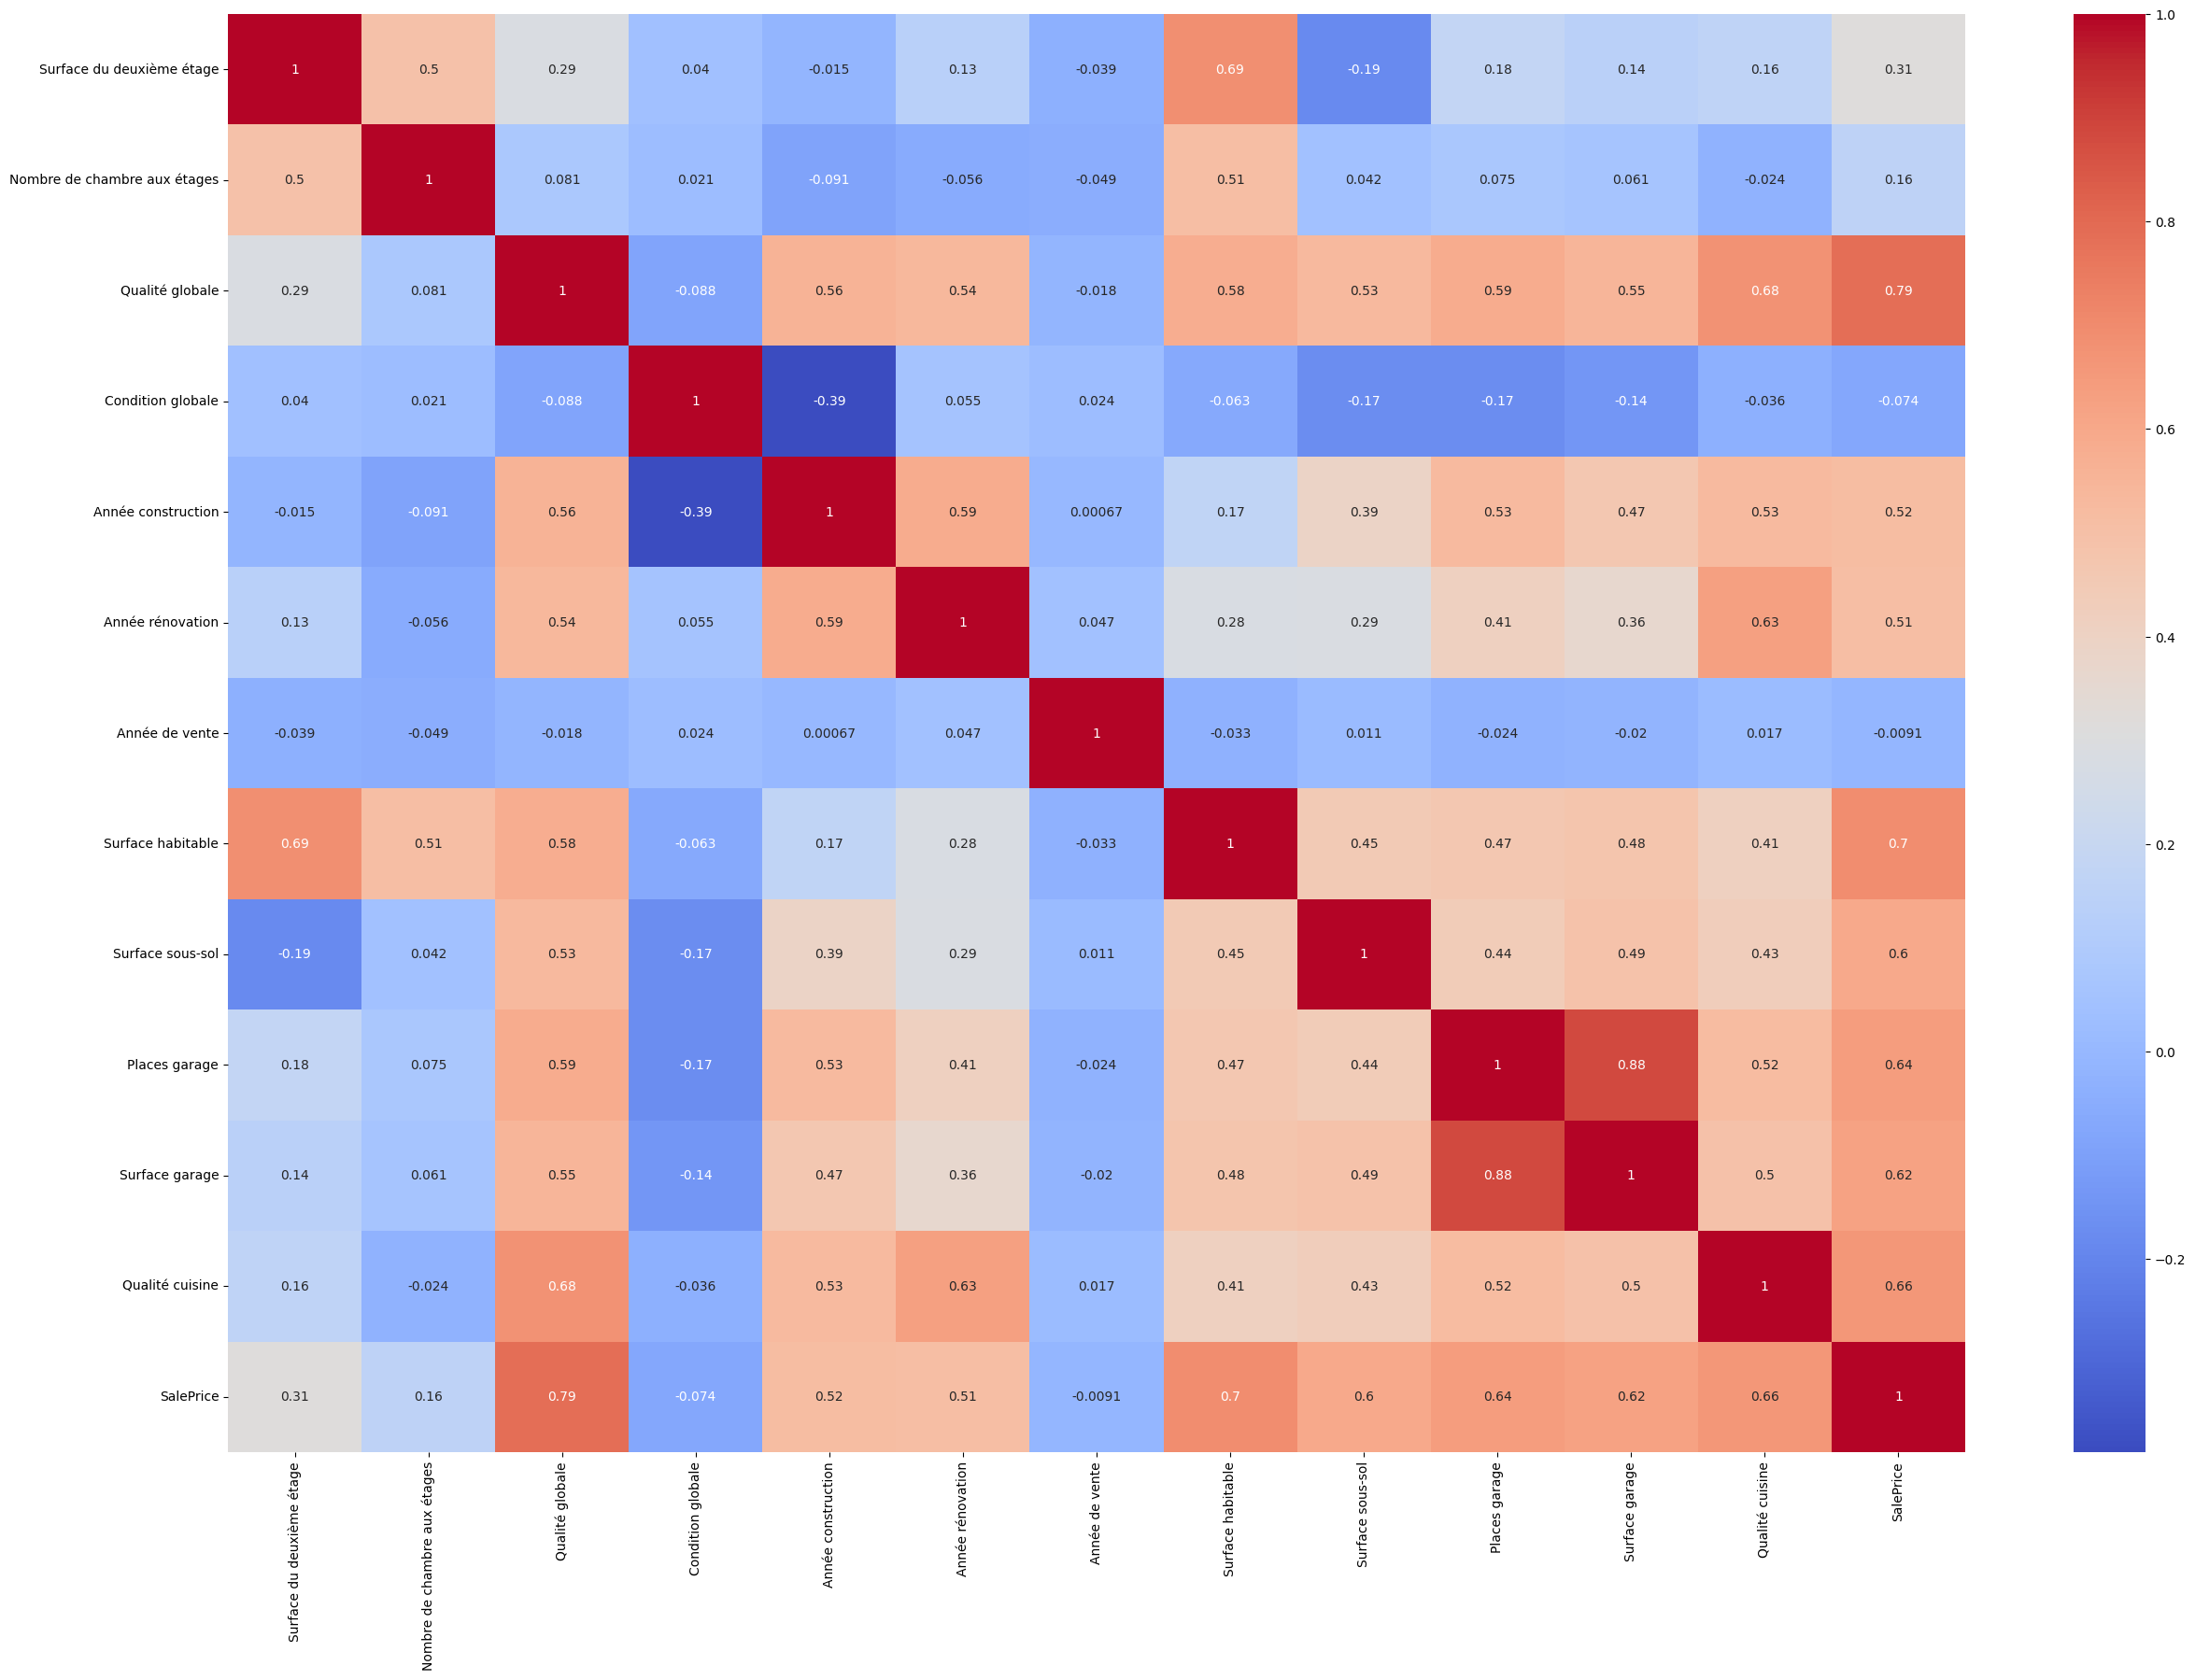

In [12]:
plt.figure(figsize=(30, 20))
df_zoom=X_train[["Surface du deuxième étage","Nombre de chambre aux étages","Qualité globale","Condition globale","Année construction","Année rénovation","Année de vente","Surface habitable","Surface sous-sol","Places garage","Surface garage","Qualité cuisine"]]   
df_zoom=pd.concat([df_zoom,y_train],axis=1)
sns.heatmap(df_zoom.corr(), annot=True,cmap="coolwarm")  


__b) Interprétation__

On peut voir à partir de la heatmap que nos données sont corrélées, aussi bien négativement que positivement.<br>
Voici quelques données remarquables :

- Corrélations positives : On remarque (sans grande surprise) que le prix et la qualité d'un logement sont très fortement corrélées (0,79). D'autres variables sont corrélées positivement, comme la surface du deuxième étage et le nombre de chambre aux étages (ce qui n'est pas étonnant car en général les chambres se situent à l'étage). 
- Corrélations négatives : La condition générale du logement semble être la variable la plus corrélée négativement à l'année de construction. A première vue, cela peut sembler étonnant car on aurait tendance à penser que plus la maison est neuve, mieux elle est entretenue. Cela peut être le signe que dans notre jeu de données, les notes de conditions les plus élevées sont souvent attribuées aux maisons les plus anciennes pour souligner leur bon état, tandis que les maisons récentes reçoivent une note standard puisqu'elles n'ont pas nécessité d'entretien particulier. 
- Absence de corrélation : Certaines variables semblent être presque indépendantes du prix de vente, comme l'année de vente par exemple. Cela peut sembler étonnant puisque l'on sait que les prix varient aussi en fonction des années (dans les années 80 les maisons n'étaient pas au même prix qu'aujourd'hui). En réalité, cela est dû au fait que notre jeu de données couvre une période très courte (2006-2010) 


Comme évoqué précédemment, la présence de liens de corrélation pourra être un point majeur qui affectera les performances de la méthode des moindres carrés dans l'interprétation des coefficients $\theta$ qui influencent le plus les prix. En effet, comme évoqué dans l'introduction, la solution des moindres carrés est donnée par<br>
$\hat{\theta} = (X^T X)^{-1}X^T y$.<br>
Or les variables explicatives sont très corrélées, alors la matrice $(X^T X)$ devient difficile à inverser car son déterminant est très proche de zéro donc pour calculer l'inverse de cette matrice l'ordinateur doit manipuler (en particulier diviser par) des chiffres extrêmement proches de 0. Alors les erreurs d'arrondi s'accumulent et font exploser le coefficient $\theta$ qui ne représente donc plus la réalité du marché.

In [13]:
det =np.linalg.det(X_train.corr())
print("Déterminant de la matrice de corrélation : ",det)
if np.abs(det)<0.000001:
    print("Déterminant très proche de 0  --> Données très corrélées")

Déterminant de la matrice de corrélation :  -7.335574978739511e-29
Déterminant très proche de 0  --> Données très corrélées


Toutefois, il est important de noter que bien que les données soient corrélées, si le jeu de données est très volumineux, la méthode des moindres carrés pourra afficher une performance plutôt satisfaisante en termes de __precision__ (le problème d'interprétation lui peut subsister). Plus intuitivement, si les observations sont nombreuses, le modèle disposera de nombreux points de comparaison, donc la droite de régression finira par se stabiliser naturellement. 
On essaiera donc par la suite d'observer cette différence en restreignant manuellement la quantité d'observations de notre jeu de données.<br><br>

Par ailleurs, une performance décevante de la méthode des moindres carrés ne s'explique pas seulement par la multicolinéarité des données. En effet, d'autres critères importants peuvent faire échouer la méthode :<br>
- La non-linéarité des données : Le modèle part du principe que la relation entre les variables et le prix est une ligne droite. Cependant, doubler la surface ne fait pas toujours doubler le prix.
- La non constance de l'erreur (hétéroscédasticité) : Le modèle doit être aussi précis peu importe le prix des maisons. Cependant, dans l'immobilier, l'erreur est souvent plus grande sur les maisons dont le prix est élevé (si le prix d'une maison de 5,1M on peut facilement négocier à 5M) 
- La présence de valeurs aberrantes : Les valeurs aberrantes sont des observations qui s'éloignent considérablement de la tendance globale des données. Une seule maison vendue à un prix non-habituel peut fausser toute la ligne de régression. Si le modèle se trompe de 2euros, l'erreur compte pour $2^2=4$ euros. Mais si le modèle rencontre une valeur extrême (par exemple s'il evalue une maison à 5,1M euros alors qu'elle est vendue 5M), l'erreur est de $100 000^2=10Md$ euros. Pour réduire cette erreur, le modèle va déplacer toute sa droite de régression vers le point extrême, au risque de devenir mauvais pour les autres maisons.

__Références__ 

TP1 du cours d'Introduction au Machine Learning (pour le code de la heatmap) <br>
https://fastercapital.com/fr/contenu/Moins-carres-ponderes---gerer-l-heteroscedasticite-avec-precision.html#Les-limites-des-moindres-carr-s-ordinaires-OLS



<br><br><br>
### III. Analyse des méthodes de moindres carrés ordinaires sur notre jeu de données

__Point de vocabulaire :__ 

Au cours du projet, nous analyserons plusieurs types d'erreurs. Voici leur signification : 
- MAE (train) : mesure l'erreur moyenne sur les données d'entraînement (que le modèle a déjà vues).
Si elle est élevée, le modèle est trop simple (underfitting).
Si elle est trop faible, sa valeur doit être comparée à celle du test pour détecter un éventuel overfitting.
Formule : $\frac{1}{n_{train}} \sum |y_{train} - \hat{y}_{train}|$
MAE (test) : mesure l'erreur moyenne sur les nouvelles données (mesure la capacité de généralisation du modèle).
Plus elle est faible, meilleur est le modèle.
Formule : $\frac{1}{n_{test}} \sum |y_{test} - \hat{y}_{test}|$
- Gap de généralisation : différence entre MAE test et MAE train.
Plus le gap est élevé, moins le modèle est robuste (overfitting)
Plus le gap est faible, plus la capacité de généralisation du modèle est bonne.
- Score $R^2$ : coefficient de détermination, mesure la proportion de la variance expliquée par le modèle.
Si $R^2 = 1$ : les prédictions sont exactes.
Si $R^2 = 0.80$, le modèle explique 80% des variations de prix, les 20% restants sont dus à des facteurs inconnus (bruit).
Si $R^2 < 0$ , le modèle est catastrophique (moins bon qu'une simple moyenne).
Formule : $1 - \frac{\text{Somme des Carrés des Résidus (SSE)}}{\text{Somme des Carrés Totale (SST)}}$

__a) La méthode des moindres carrés ordinaires__ 

Comme expliqué lors de l'introduction, la solution optimale de la méthode des moindres carrés est donnée par
$\hat{\theta} = (X^T X)^{-1}X^T y$. On peut alors mettre en place le code suivant :

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [15]:
print("Nombre total de NaN :", X_train.isna().sum().sum())

Nombre total de NaN : 223


On remarque que dans notre jeu de données, même s'il n'y a plus de colonnes textuelles, il y a encore des lignes (maisons) avec des données manquantes (les NaN). Il faut donc trouver un moyen de les convertir en des données numériques, sinon la méthode des moindres carrés ne sera pas bien définie. <br>
Une solution possible et de remplacer ces valeurs manquantes par la médiane de la colonne correspondante. Cela permettra de ne pas donner de valeurs absurdes qui pourraient influencer la valeur des coefficients theta et fausser notre modèle. On va aussi transformer tous les booléens en 0 ou 1 pour les mêmes raisons (même si à priori ils devraient être considérés comme des variables binaires numériques 0 ou 1).

Coefficient pour  MSSubClass :  -13255.113991573966
Coefficient pour  LotFrontage :  -3943.6457685506284
Coefficient pour  Surface du terrain :  2640.7120367060543
Coefficient pour  Neighborhood :  15303.979668835149
Coefficient pour  Qualité globale :  15151.01580080171
Coefficient pour  Condition globale :  6240.660865309159
Coefficient pour  Année construction :  613.9327715946492
Coefficient pour  Année rénovation :  -2751.240144342767
Coefficient pour  Exterior1st :  393.8357438017447
Coefficient pour  MasVnrArea :  4139.759590136986
Coefficient pour  Qualité extérieure :  3829.7100867865993
Coefficient pour  ExterCond :  -334.88605712946605
Coefficient pour  BsmtQual :  5752.455867744158
Coefficient pour  BsmtCond :  -1885.2306898402971
Coefficient pour  BsmtExposure :  5525.868593418978
Coefficient pour  BsmtFinType1 :  2713.4360746998336
Coefficient pour  BsmtFinSF1 :  2789.8762014880404
Coefficient pour  BsmtUnfSF :  -74.90257288760586
Coefficient pour  Surface sous-sol :  822

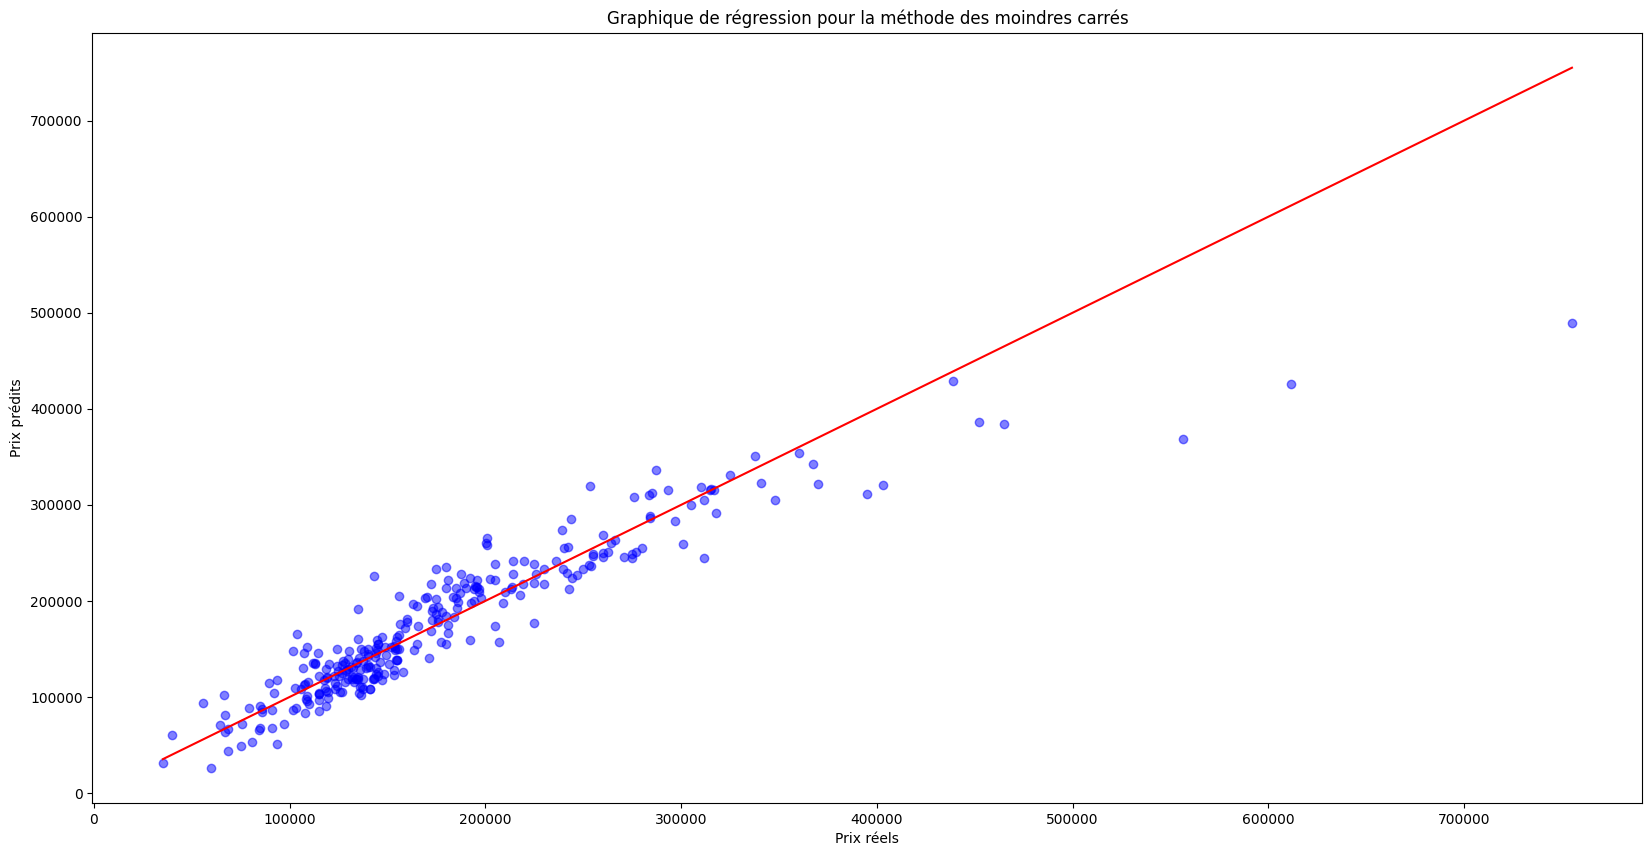

In [16]:
# Nettoyage
X_train = X_train.fillna(X_train.median()) # On remplace les NaN par la median de la colonne
X_test = X_test.fillna(X_train.median())


sc = StandardScaler()
X_train_standard = sc.fit_transform(X_train)
X_test_standard = sc.transform(X_test) #on applique la même transformation sur le test
X_train_mco=np.c_[np.ones(X_train_standard.shape[0]),X_train_standard] #On rajoute une colonne de 1, cela permet de calculer l'ordonnée à l'origine
X_test_mco=np.c_[np.ones(X_test_standard.shape[0]),X_test_standard] #On rajoute une colonne de 1, cela permet de calculer l'ordonnée à l'origine


#On calcule le theta optimal de la méthode des moindres carrés ordinaires
XTX=np.dot(X_train_mco.T, X_train_mco)
XTy=np.dot(X_train_mco.T, y_train)
teta_optimal=np.linalg.inv(XTX).dot(XTy) 

#Prédiction du modèle
y_pred=np.dot(X_test_mco,teta_optimal)

#Analyse des resultats
mae_test_mco = np.mean(np.abs(y_pred - y_test))
y_pred_train=np.dot(X_train_mco,teta_optimal)
mae_train_mco=np.mean(np.abs(y_train-y_pred_train)) 
gap_mco=mae_test_mco - mae_train_mco 

#Calcul du score R2 sur le test : 
s1=np.sum((y_pred-y_test)**2)
s2=np.sum((y_test - np.mean(y_test))**2)
score_mco=1-s1/s2


#Analyse des coefficients teta pour l'interprétation des variables qui influencent le plus les prix
i=1
for colonne in X_train.columns:
    print("Coefficient pour ",colonne, ": ",teta_optimal[i])
    i+=1

#Graphique MCO
plt.figure(figsize=(20, 10))
plt.scatter(y_test, y_pred, color="blue",alpha=0.5, label="Prédictions MCO")
ligne=[np.min(y_test),np.max(y_test)]
plt.plot(ligne,ligne,color="red",alpha=1) #ligne de perfection, si un point est parfaitement sur la ligne, c'est que le prix prédit est exact
plt.title("Graphique de régression pour la méthode des moindres carrés")
plt.xlabel("Prix réels")
plt.ylabel("Prix prédits") 

print()
print("Gap de généralisation : ",gap_mco)
print("MAE train",mae_train_mco)
print("Score : ",score_mco)



__b) L'ACP : une première solution ?__

Effectuons une ACP pour résoudre le problème de multicolinéarité et voir si une amélioration se produit. On fera attention à comparer nos deux modèles sur les mêmes données (donc on ne réeffectue pas le train/test/split, on utilise le découpage déjà effectué plus haut)

In [17]:

pca = PCA(n_components=0.95) #on garde 95% de l'information et on élimine les 5% de bruit restant pour stabiliser le modèle

X_train_acp = pca.fit_transform(X_train_standard) 
X_test_acp = pca.transform(X_test_standard)
X_train_acp = np.c_[np.ones(X_train_acp.shape[0]), X_train_acp] #On rajoute une colonne de 1 pour calculer les prix à l'origine
X_test_acp = np.c_[np.ones(X_test_acp.shape[0]), X_test_acp]

#Moindres carrés ordinaires avec ACP
XTX=np.dot(X_train_acp.T, X_train_acp)
XTy=np.dot(X_train_acp.T, y_train)
teta_optimal_acp=np.linalg.inv(XTX).dot(XTy)
y_pred_acp = np.dot(X_test_acp, teta_optimal_acp)

#Analyse de la CP1
tableau = pd.DataFrame(pca.components_.T, index=X_train.columns)
print("Top 10 des variables qui forment la CP1 :")
print(tableau[0].sort_values(ascending=False).head(10))
variance_cp1=pca.explained_variance_ratio_[0]*100
variance_totale = pca.explained_variance_ratio_.sum() * 100
print()
print("CP1 explique à elle seule ",variance_cp1," % de l'information totale.")
print("On a compressé 77 variables en ", pca.n_components_," axes indépendants.")
print("Ces axes indépendants résument ",variance_totale," %de l'information totale.")



Top 10 des variables qui forment la CP1 :
Qualité globale       0.230912
Année construction    0.216775
Qualité extérieure    0.215395
Neighborhood          0.215104
Places garage         0.209266
BsmtQual              0.208902
Qualité cuisine       0.207790
GarageFinish          0.203933
Surface garage        0.200803
Surface sous-sol      0.187662
Name: 0, dtype: float64

CP1 explique à elle seule  16.370407500653897  % de l'information totale.
On a compressé 77 variables en  53  axes indépendants.
Ces axes indépendants résument  95.34783883546808  %de l'information totale.


L'ACP a donc permis de simplifier notre modele en réduisant sa dimension. Nous sommes passés de 77 variables initiales à 52 composantes principales qui suffisent à résumer 95% de l'information. Cela signifie que les 25 dimensions restantes n'apportaient que 5% de l'information, correspondant principalement à du bruit. <br>

Analysons désormais les performances de la méthode des moindres carrés sur nos données projetées sur ces 52 axes.

In [18]:
#Analyse des resultats
mae_test_acp = np.mean(np.abs(y_pred_acp - y_test))  
y_pred_train_acp=np.dot(X_train_acp,teta_optimal_acp)
mae_train_acp=np.mean(np.abs(y_train-y_pred_train_acp))
gap_acp=mae_test_acp - mae_train_acp

#Calcul du score sur le test : 
s1=np.sum((y_pred_acp-y_test)**2)
s2=np.sum((y_test - np.mean(y_test))**2)
score_acp=1-s1/s2

tab1= {
    "Modèle": ["MCO Classique", "MCO avec ACP"],
    "MAE test": [mae_test_mco,mae_test_acp],
    "Gap de généralisation ": [gap_mco,gap_acp],
    "MAE train ": [mae_train_mco,mae_train_acp]
}

print(pd.DataFrame(tab1))



          Modèle      MAE test  Gap de généralisation     MAE train 
0  MCO Classique  20600.015955             1704.493229  18895.522725
1   MCO avec ACP  21252.719043             1964.630183  19288.088860


__A priori, on ne voit pas vraiment de grand progrès__<br>
Cependant, on ne peut pas s'arrêter ici. Analysons les matrices de corrélation : 

Text(0.5, 1.0, 'Matrice de corrélation après ACP')

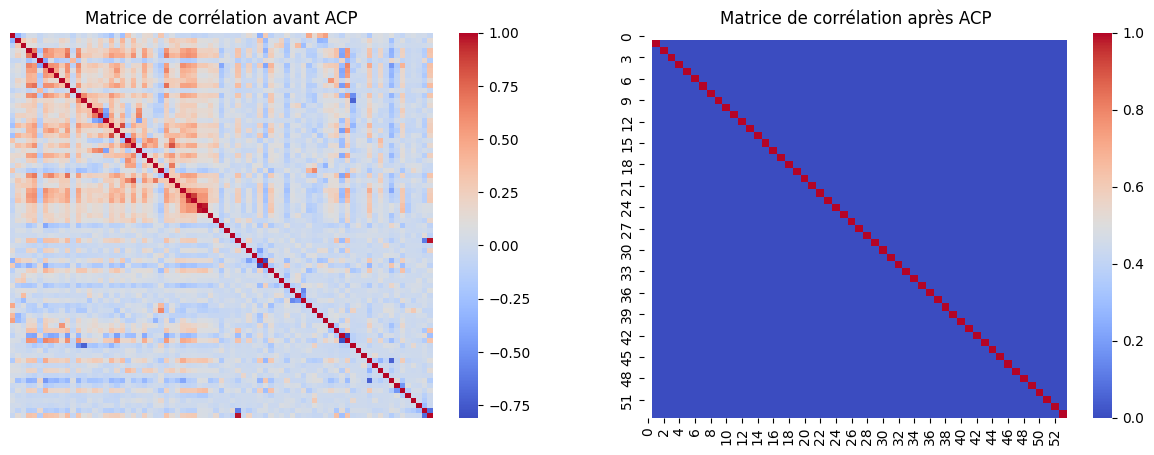

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(X_train.corr(), cmap='coolwarm',xticklabels=False, yticklabels=False,ax=axes[0])
axes[0].set_title("Matrice de corrélation avant ACP")

df_acp = pd.DataFrame(X_train_acp)
sns.heatmap(df_acp.corr(), cmap='coolwarm',ax=axes[1])
axes[1].set_title("Matrice de corrélation après ACP")

On remarque donc que l'on a plus de corrélation entre les données. <br>
__Alors pourquoi l'ACP ne semble pas améliorer la performance du modèle ?__

Comme expliqué lors de l'introduction, notre jeu de données contient une multitude de données (1460 lignes, 77 colonnes).<br>
Si les observations sont nombreuses, le modèle disposera de nombreux points de comparaison, donc la droite de régression finira par se stabiliser naturellement. Essayons donc de restreindre manuellement la quantité d'observations de notre jeu de données.<br><br>

In [20]:
#Réduction du nombre de maisons
nb_observations=500
X_train_standard_reduit = X_train_standard[:nb_observations]
y_reduit = y_train[:nb_observations]


MAE test : 1729846.3896547123
Gap de généralisation :  1137223.263917754
MAE train :  592623.1257369583
Score :  -42013.71906390429


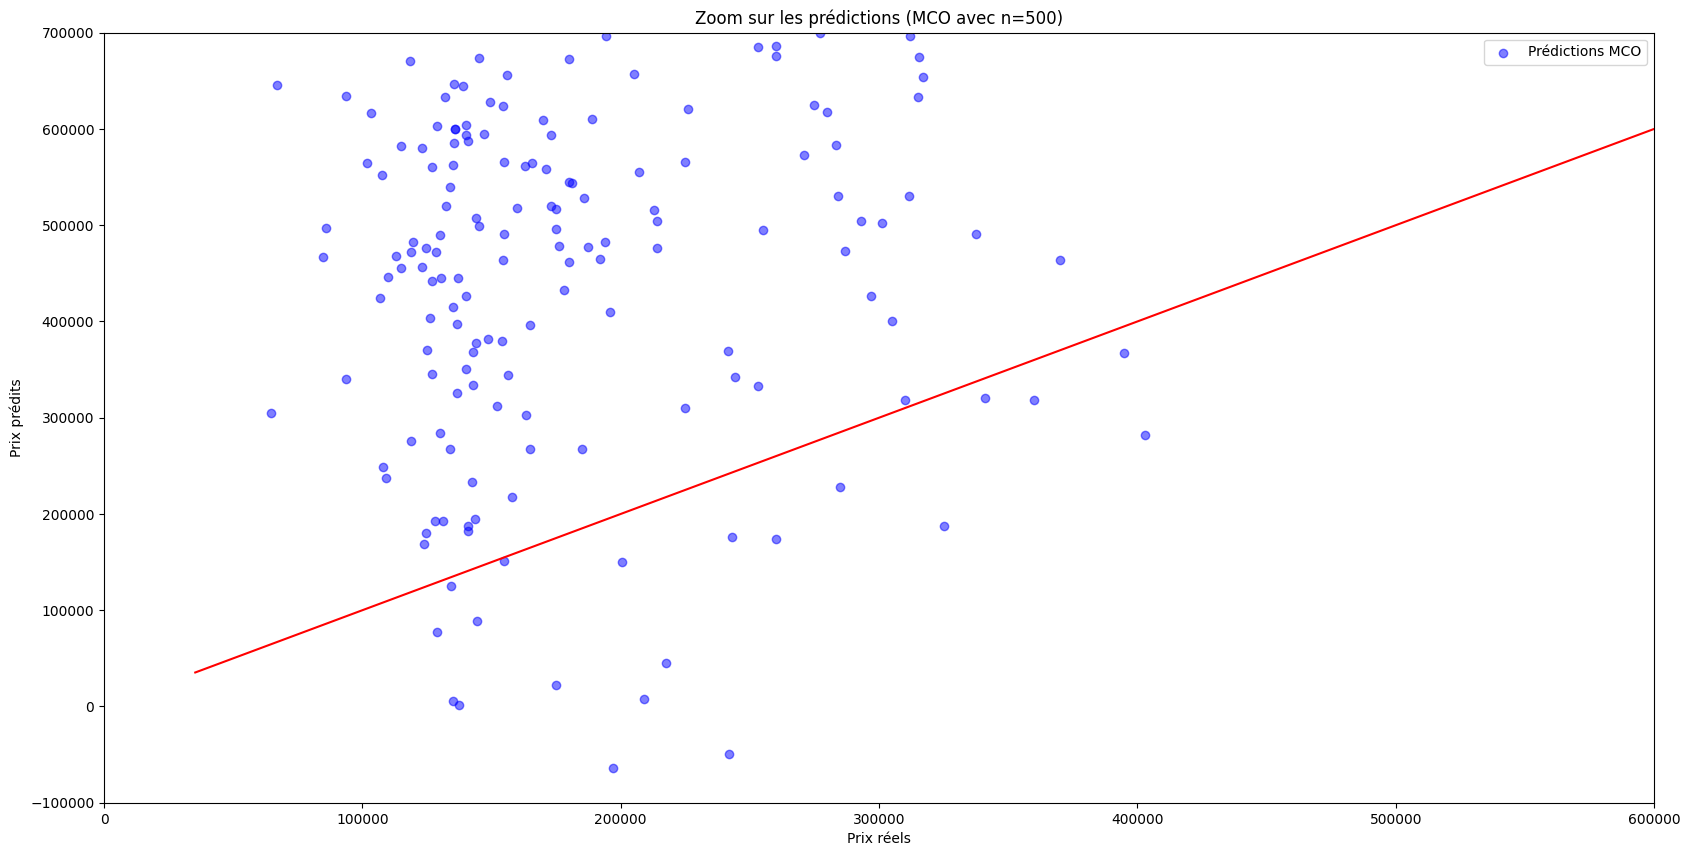

In [21]:
#Meme code que précedemment 

X_reduit_mco = np.c_[np.ones(X_train_standard_reduit.shape[0]), X_train_standard_reduit] #On rajoute une colonne de 1 pour calculer les prix à l'origine


#On calcule le theta optimal de la méthode des moindres carrés ordinaires
XTX=np.dot(X_reduit_mco.T, X_reduit_mco)
XTy=np.dot(X_reduit_mco.T, y_reduit)
teta_optimal=np.linalg.inv(XTX).dot(XTy)

#Prédiction du modèle
y_pred=np.dot(X_test_mco,teta_optimal)

#Analyse des resultats
mae_test_mco_reduit = np.mean(np.abs(y_pred - y_test))  
y_pred_train=np.dot(X_reduit_mco,teta_optimal)
mae_train_mco_reduit=np.mean(np.abs(y_reduit-y_pred_train))
gap_mco_reduit=mae_test_mco_reduit - mae_train_mco_reduit

#Calcul du score sur le test : 
s1=np.sum((y_pred-y_test)**2)
s2=np.sum((y_test - np.mean(y_test))**2)
score_mco_reduit=1-s1/s2


#Graphique MCO
plt.figure(figsize=(20, 10))
plt.scatter(y_test, y_pred, color="blue",alpha=0.5, label="Prédictions MCO")
ligne=[np.min(y_test),np.max(y_test)]
plt.plot(ligne,ligne,color="red",alpha=1) #ligne de perfection, si un point est parfaitement sur la ligne, c'est que le prix prédit est exact
plt.title("Graphique de régression pour la méthode des moindres carrés avec diminution du nombre d'observations")
plt.xlabel("Prix réels")
plt.ylabel("Prix prédits") 

print()
print("MAE test :", mae_test_mco_reduit)
print("Gap de généralisation : ",gap_mco_reduit)
print("MAE train : ",mae_train_mco_reduit)
print("Score : ",score_mco_reduit)

#ZOOM
plt.ylim(-100000, 700000) 
plt.xlim(0, 600000)
plt.title("Zoom sur les prédictions (MCO avec n=500)")
plt.xlabel("Prix réels")
plt.ylabel("Prix prédits")
plt.legend()
plt.show()

__Attention : regardez bien l'échelle sur l'axe des ordonnées__ <br>
On voit que les résultats sont totalement absurdes, avec un score négatif et des erreurs en millions d'euros. Cela revient à dire que le modèle prédit moins bien que la simple moyenne des prix. C'est bien le signe que notre matrice XTX est mal conditionnée : les coefficients theta ont explosé et le modèle a sur-réagit. On pourra relancer le code plusieurs fois sans le random_state pour réaliser que les résultats sont aussi extrêmement différents en fonction du train/test/split effectué ce qui prouve que le modèle réagit au moindre bruit, jusqu'à avoir un score négatif et un gap de généralisation en millions d'euros. On est donc dans un cas fort d'overfitting.


MAE test avec ACP : 24330.3457547811
MAE test sans ACP : 1729846.3896547123
Gap de généralisation avec ACP :  4174.697439844756
Gap de généralisation sans ACP :  1137223.263917754

MAE train avec ACP 20155.648314936345
MAE train sans ACP 592623.1257369583

Score R2 avec ACP :  0.8020521006355923
Score R2 sans ACP :  -42013.71906390429


Text(0, 0.5, 'Prix prédits')

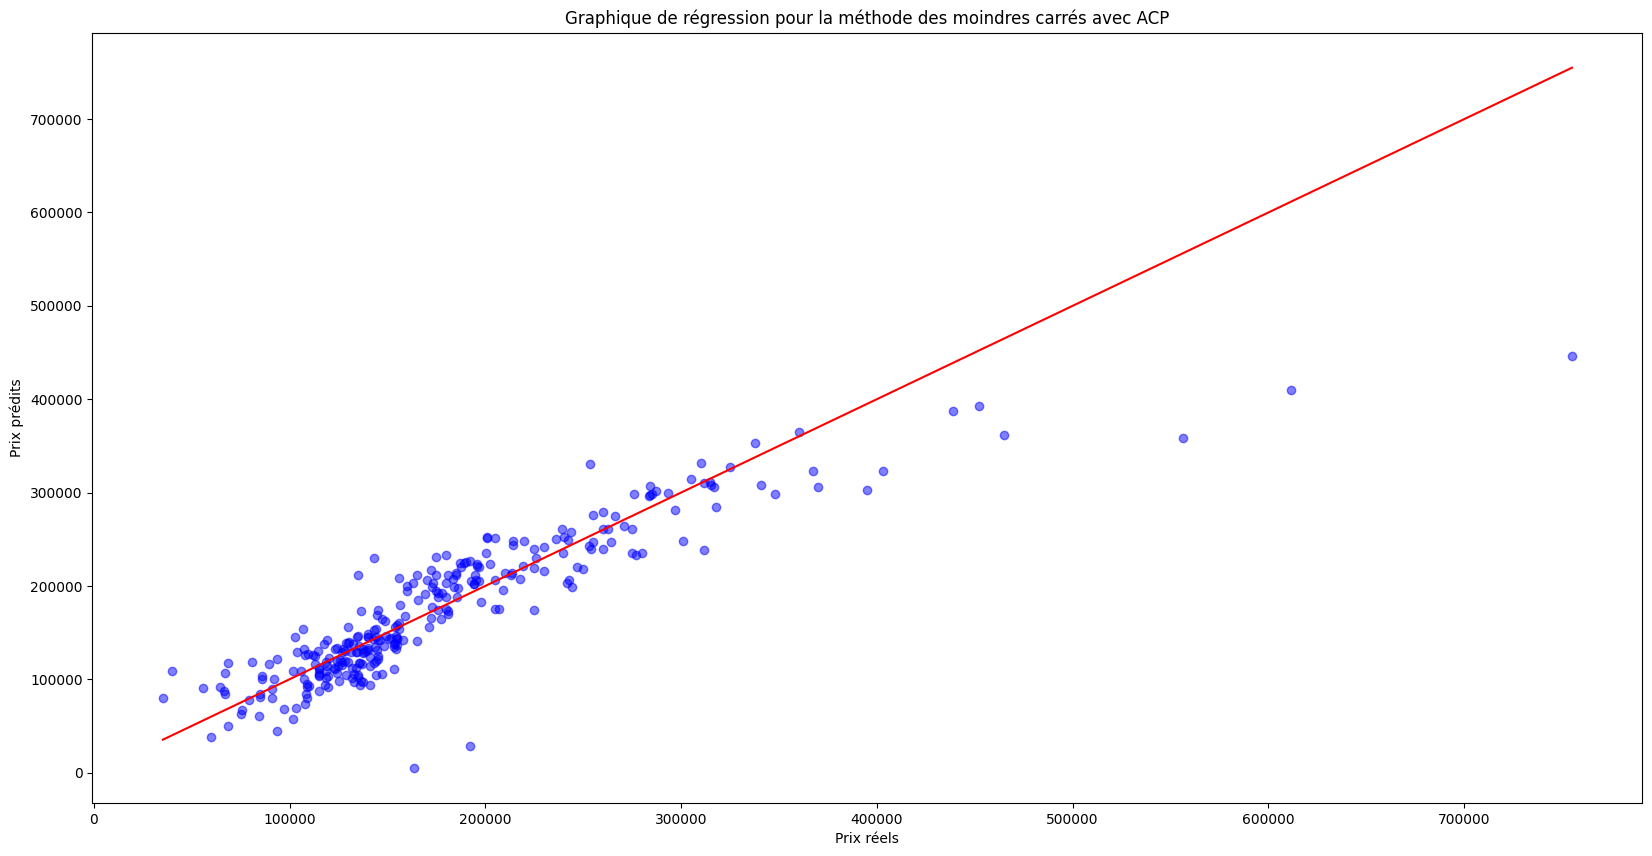

In [22]:
#On refait l'ACP, même code 


pca = PCA(n_components=0.95) 

X_train_acp_reduit = pca.fit_transform(X_train_standard_reduit) 
X_test_acp_reduit = pca.transform(X_test_standard)
X_train_acp_reduit = np.c_[np.ones(X_train_acp_reduit.shape[0]), X_train_acp_reduit] #On rajoute une colonne de 1 pour calculer les prix à l'origine
X_test_acp_reduit = np.c_[np.ones(X_test_acp_reduit.shape[0]), X_test_acp_reduit]

#Moindres carrés ordinaires avec ACP
XTX=np.dot(X_train_acp_reduit.T, X_train_acp_reduit)
XTy=np.dot(X_train_acp_reduit.T, y_reduit)
teta_optimal_acp_reduit=np.linalg.inv(XTX).dot(XTy)
y_pred_acp_reduit = np.dot(X_test_acp_reduit, teta_optimal_acp_reduit)

#Analyse des resultats
mae_test_acp_reduit= np.mean(np.abs(y_pred_acp_reduit - y_test)) 
y_pred_train_acp_reduit=np.dot(X_train_acp_reduit,teta_optimal_acp_reduit)
mae_train_acp_reduit=np.mean(np.abs(y_reduit-y_pred_train_acp_reduit))
gap_acp_reduit= mae_test_acp_reduit - mae_train_acp_reduit

#Calcul du score R2 sur le test (pourcentage de réussite)
s1=np.sum((y_pred_acp_reduit-y_test)**2)
s2=np.sum((y_test - np.mean(y_test))**2)
score_acp_reduit=1-s1/s2

#Comparaison
print()
print("MAE test avec ACP :", mae_test_acp_reduit)
print("MAE test sans ACP :", mae_test_mco_reduit)

print("Gap de généralisation avec ACP : ",gap_acp_reduit)
print("Gap de généralisation sans ACP : ",gap_mco_reduit)
print()
print("MAE train avec ACP",mae_train_acp_reduit)
print("MAE train sans ACP",mae_train_mco_reduit)
print()
print("Score R2 avec ACP : ",score_acp_reduit)
print("Score R2 sans ACP : ",score_mco_reduit)

#Graphique MCO avec ACP
plt.figure(figsize=(20, 10))
plt.scatter(y_test, y_pred_acp_reduit, color="blue",alpha=0.5, label="Prédictions MCO")
ligne=[np.min(y_test),np.max(y_test)]
plt.plot(ligne,ligne,color="red",alpha=1) #ligne de perfection, si un point est parfaitement sur la ligne, c'est que le prix prédit est exact
plt.title("Graphique de régression pour la méthode des moindres carrés avec ACP")
plt.xlabel("Prix réels")
plt.ylabel("Prix prédits") 




__c) Conclusion sur la méthode des moindres carrés__
<br>

Notre étude a prouvé que la méthode des moindres carrés, bien qu'efficace sur un un grand jeu de données, s'effondre face à la multicolinéarité des données lorsque l'on réduit le nombre d'observations. En conséquence, des résultats totalement absurdes se produisent : erreurs en millions d'euros, score négatif, coefficients extrêmes.<br>
L'ACP, en transformant nos variables pour les rendre orthogonales, a permis de résoudre notre problème. Le résultat est sans équivoque : le modèle devient beaucoup plus précis (score autour de 0.8), mais surtout beaucoup plus stable (que ce soit avant ou après la restriction du nombre d'observations, le modèle affiche toujours les mêmes performances.Toutefois, un problème subsiste : l'interprétation des résultats.En effet, en projetant les données sur de nouveaux axes, on ne peut plus interpréter quels facteurs influencent le plus les prix.<br>

Heureusement, des solutions existent. En particulier, la méthode de régularisation Ridge, en ajoutant une pénalisation (contrainte sur les coefficients theta qui ne peuvent plus exploser), offre un compromis intéressant entre la précision du modèle et son interprétation.  



__Pour aller plus loin__ 

En réalité, les problèmes que l'on a rencontré, sont quasiment tous dus au fait que pour calculer notre coefficient teta_optimal, nous avons effectué une inversion classique en utilisant np.linalg.inv. Puisque nos données sont corrélées, le déterminant de cette matrice est très proche de 0, et l'inversion se passe mal, ce qui conduit à une explosion des coefficients $\theta$. 

Cependant, il existe d'autres méthodes pour inverser des matrices (décomposition LU, Cholesky etc.). Ainsi, remplacer la ligne 
teta_optimal=np.linalg.inv(XTX).dot(XTy) par <br>
teta_optimal=np.linalg.solve(XTX,XTy) 
résoud notre problème. 

De la même façon, on aurait pu utiliser directement les fonctions de la bibliotheque sickit_learn pour effectuer la méthode des moindres carrés, ce qui aurait rendu nos résultats beaucoup plus stables.<br>

Ici, notre intérêt était plutôt pédagogique, le but étant simplement de voir comment une ACP permet de résoudre les problèmes de multicolinéarité d'un jeu de données.

D'autre part, même si des outils comme np.linalg.solve ou scikit-learn permettent de stabiliser notre modèle, ils ne règlent pas le problème de la signification des coefficients. Prenons l'exemple de deux variables : nombres de pièces et surface totale. Elles sont fortement corrélées.
À cause de la multicolinéarité, le modèle peut attribuer +50 000 € à la surface et -40 000 € au nombre de pièces.
Le résultat final (la prédiction) sera juste, mais l'explication est fausse. On ne peut pas dire qu'ajouter une pièce fait perdre 40 000 € à une maison.

L'ACP résout ce dilemme en créant des axes qui ne sont plus corrélés entre eux. L'ACP va fusionner la "Surface" et le "Nombre de pièces" dans une seule composante principale. Comme chaque composante principale est indépendante des autres, le coefficient associé à cette composante devient fiable.
De plus,en ne gardant que les premières composantes, on élimine les petites variations (le bruit) qui perturbaient l'estimation des coefficients.<br><br><br>

### IV. Méthodes de pénalisation pour la régularisation des modèles

__1. Pourquoi pénaliser les modèles ?__

Plutôt que de chercher à minimiser l'erreur de prédiction (la somme des carrés des résidus $\sum_{i=1}^{m} (y_i - \hat{y}_i)^2$), les méthodes de régression avec pénalité ajoutent une pénalité à la fonction de coût dans le but de décourager le modèle d'adopter des coefficients trop grands. On cherche donc à minimiser $\frac{1}{n} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2 + Pénalité (\theta)$ <br>

La régression LASSO ajoute une pénalité proporitionnelle à la somme des valeurs absolues des coefficients  $\lambda \sum_{i=1}^{n} |\theta|$<br>
Elle permet de rétrécir les coefficients, qui peuvent devenir nuls. Cette méthode est idéale pour simplifier le modèle en accordant des coefficients nuls aux variables peu pertinentes. 

La régression Ridge ajoute une pénalité proporitionnelle à la somme des carrés des coefficients $\lambda \sum_{i=1}^{n} \theta^2$<br>
Elle force les coefficients à devenir très petits sans jamais devenir nuls. Cette méthode est idéale pour gérer la multicolinéarité en forçant les variables corrélées à se partager le poids, plutôt que de multiplier le poids pour les variables corrélées.

__Références__

https://toussile.quarto.pub/data-science/posts/machine-learning/supervized-learning/regression/05-regularized-linear-regression.html#:~:text=Cette%20p%C3%A9nalit%C3%A9%20est%20con%C3%A7ue%20pour%20d%C3%A9courager%20le%20mod%C3%A8le,for%C3%A7ant%20%C3%A0%20rester%20plus%20petits%20et%20plus%20stables.

__2. Analyse d'une régularisation Ridge__

__a) Implémentation de la méthode en utilisant la solution $\hat{\theta}_{Ridge} = (X^TX + \lambda I)^{-1}X^Ty$ .__

Lambda optimal :  449.8432668969444


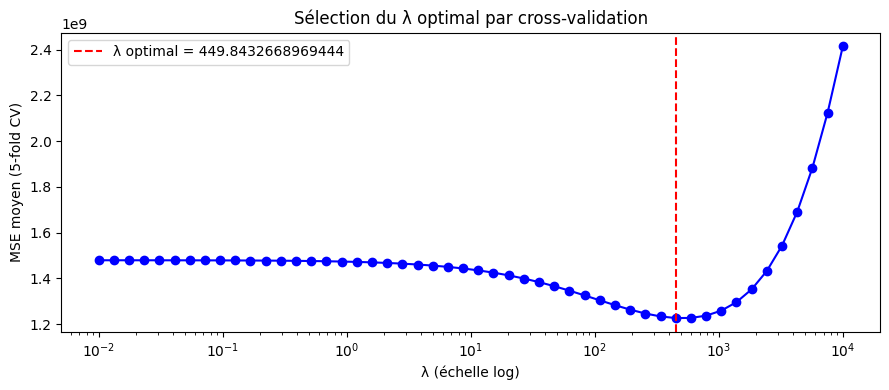

In [23]:
#On fait une 5-Fold Cross Validation pour trouver le paramètre lambda optimal
from sklearn.model_selection import KFold

X_train_ridge = np.c_[np.ones(X_train_standard.shape[0]), X_train_standard] #On rajoute la colonne de 1 pour l'intercept
X_test_ridge  = np.c_[np.ones(X_test_standard.shape[0]),  X_test_standard]

lambdas = np.logspace(-2, 4, 50) #50 points répartis de manière logarithmique entre 0.01 et 10000
kf = KFold(n_splits=5, shuffle=True, random_state=33)
cv_errors = []
for l in lambdas:
    fold_errors=[]
    for train_idx, val_idx in kf.split(X_train_ridge):
        X_f_train = X_train_ridge[train_idx]
        X_f_val =  X_train_ridge[val_idx]
        y_f_train = np.array(y_train)[train_idx]
        y_f_val = np.array(y_train)[val_idx]

        p = X_f_train.shape[1]
        I_pen = np.eye(p)   #On ne pénalise pas l'intercept
        I_pen[0, 0] = 0

        XTX = np.dot(X_f_train.T, X_f_train) + l*I_pen
        XTy = np.dot(X_f_train.T,y_f_train)
        theta = np.linalg.solve(XTX, XTy)   #solve plus stable que inv

        y_val_pred = np.dot(X_f_val,theta)
        fold_errors.append(np.mean((y_val_pred - y_f_val)**2))

    cv_errors.append(np.mean(fold_errors))
lambda_optimal = lambdas[np.argmin(cv_errors)]
print("Lambda optimal : ",lambda_optimal)

#Visualisation de la courbe de convergence
plt.figure(figsize=(9, 4))
plt.plot(lambdas, cv_errors, marker='o',color='blue')
plt.axvline(lambda_optimal, color='red', linestyle='--', label=f'λ optimal = {lambda_optimal}')
plt.xscale('log')
plt.xlabel('λ (échelle log)')
plt.ylabel('MSE moyen (5-fold CV)')
plt.title('Sélection du λ optimal par cross-validation')
plt.legend()
plt.tight_layout()
plt.show()


      


MAE test : 19866.44129778333
Gap de généralisation :  1623.3265132737797
MAE train :  18243.11478450955
Score R² :  0.8460151631650209


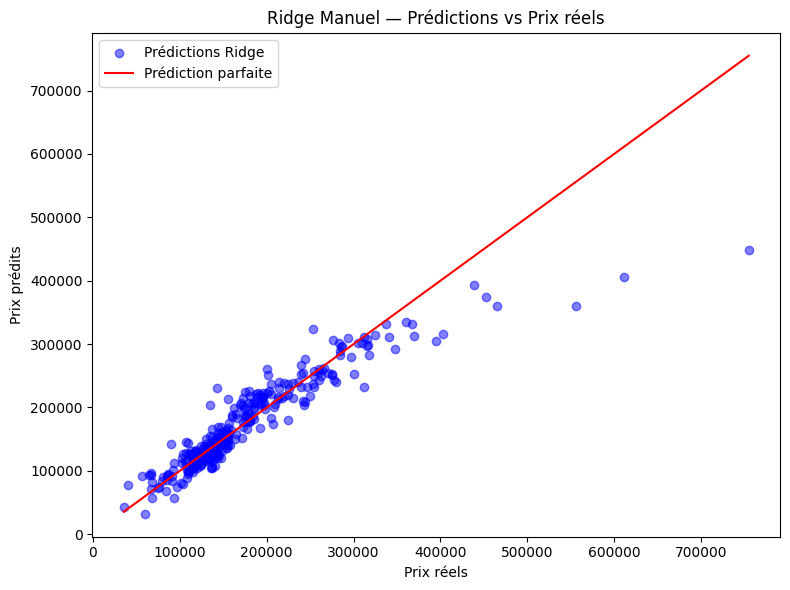

In [42]:
#On entraîne le modèle avec notre lambda optimal
X_train_ridge = np.c_[np.ones(X_train_standard.shape[0]), X_train_standard]
X_test_ridge  = np.c_[np.ones(X_test_standard.shape[0]),  X_test_standard]
p = X_train_ridge.shape[1]
I_pen = np.eye(p)
I_pen[0, 0] = 0   #on ne pénalise pas l'intercept

XTX = np.dot(X_train_ridge.T, X_train_ridge)
XTy = np.dot(X_train_ridge.T, y_train)
theta_ridge_manuel = np.dot(np.linalg.inv(XTX + lambda_optimal * I_pen),XTy) #remarque : on pourrait utiliser linalg.solve pour plus de stabilité mais on a préféré garder linalg.inv pour d'avantage de justesse dans notre comparaison avec MCO 
y_pred_ridge_manuel = np.dot(X_test_ridge,theta_ridge_manuel)

# Métriques
mae_test_ridge  = np.mean(np.abs(y_pred_ridge_manuel - y_test))
mae_train_ridge = np.mean(np.abs(y_train - (np.dot(X_train_ridge,theta_ridge_manuel))))
gap_ridge = mae_test_ridge - mae_train_ridge
s1 = np.sum((y_pred_ridge_manuel - y_test)**2)
s2 = np.sum((y_test-np.mean(y_test))**2)
score_ridge = 1 - s1/s2


print("MAE test :", mae_test_ridge)
print("Gap de généralisation : ", gap_ridge)
print("MAE train : ", mae_train_ridge)
print("Score R² : ", score_ridge)

#Graphique
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_ridge_manuel, alpha=0.5, color='blue', label='Prédictions Ridge')
lim = [np.min(y_test), np.max(y_test)]
plt.plot(lim, lim, color='red', linewidth=1.5, label='Prédiction parfaite')
plt.xlabel('Prix réels')
plt.ylabel('Prix prédits')
plt.title('Ridge Manuel — Prédictions vs Prix réels')
plt.legend()
plt.tight_layout()
plt.show()


__c) Implémentation avec scikit-learn (RidgeCV)__

`RidgeCV` effectue une cross-validation interne pour sélectionner automatiquement le meilleur paramètre de régularisation dans la liste fournie. C'est la façon standard d'utiliser Ridge en pratique.

In [43]:
from sklearn.linear_model import RidgeCV

#sélection du lambda optimal
alphas = np.logspace(-2, 4, 50)
model_ridge = RidgeCV(alphas=alphas, cv=5)  #on effectue une 5-fold cross validation
model_ridge.fit(X_train_standard, y_train) #on entraîne le model sur le jeu d'entrainement
y_pred_ridge = model_ridge.predict(X_test_standard) #predictions du modele
alpha_optimal = model_ridge.alpha_ 
print("Lambda optimal", alpha_optimal)

#Analyse des résultats
y_train_pred = model_ridge.predict(X_train_standard)
mae_test_ridge_final = np.mean(np.abs(y_pred_ridge - y_test))
mae_train_ridge_final = np.mean(np.abs(y_train - y_train_pred))
gap_ridge_final = mae_test_ridge_final - mae_train_ridge_final
score_ridge_final = model_ridge.score(X_test_standard, y_test)

print("MAE test :", mae_test_ridge_final)
print("Gap de généralisation : ", gap_ridge_final)
print("MAE train : ", mae_train_ridge_final)
print("Score R² : ", score_ridge_final)



Lambda optimal 255.95479226995332
MAE test : 19719.963622347408
Gap de généralisation :  1568.7198149130163
MAE train :  18151.24380743439
Score R² :  0.8528186670034059


Remarque : On note une différence entre le $\lambda$ optimal de notre modèle manuel et celui de Scikit-Learn (255). Cela s'explique par les différences de conventions de calcul : Scikit-Learn minimise l'erreur quadratique moyenne (MSE) tandis que notre modèle manuel travaille sur la somme des carrés (RSS), et les implémentations de la standardisation peuvent varier. Toutefois, les résultats MAE et gap sont cohérents, en accord avec nos résultats manuels, même si le paramètre lambda n'est pas exactement le même. C'est plutôt rassurant puisque cela indique que notre code manuel était plutôt bon

__d) Ridge sur le jeu de données réduit (n=500) — là où le MCO s'effondrait__

On reprend le code manuel pour calculer le theta optimal, puisqu'on avait utilisé la méthode manuelle pour MCO, cela permet de comparer les deux modèles de manière équitable (en particulier on continue d'utiliser np.linalg.inv). On peut garder la méthode RidgeCV pour avoir une meilleure estimation pour le paramètre lambda.

Lambda optimal 449.8432668969444
MAE de test : 21861.35379851994
Gap de généralisation :  1509.2806512412426
MAE train :  20352.073147278697
Score R² :  0.8035078918173497


Text(0, 0.5, 'Prix prédits')

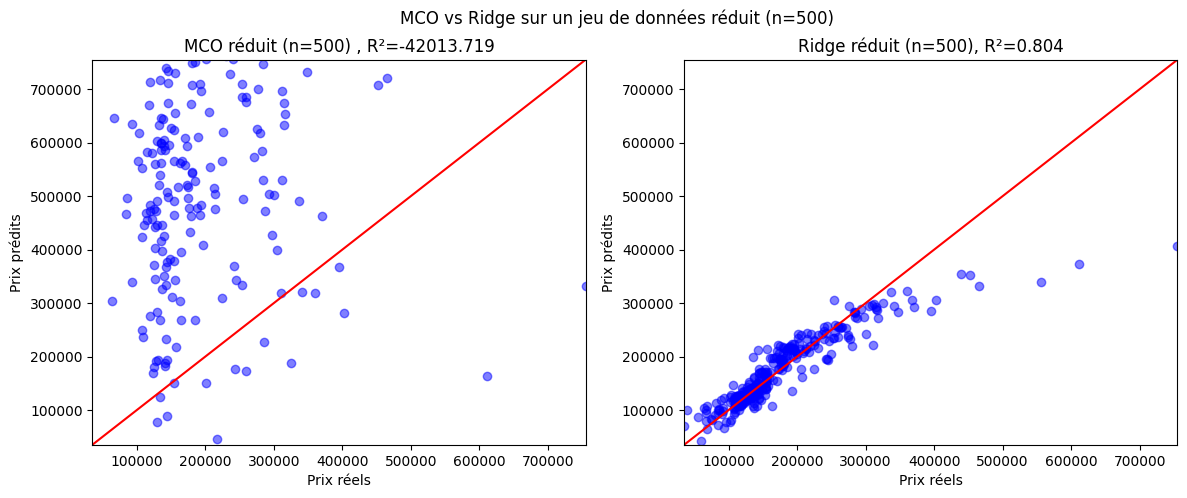

In [26]:
X_train_ridge = np.c_[np.ones(X_train_standard_reduit.shape[0]), X_train_standard_reduit] #On rajoute la colonne de 1 pour l'intercept
X_test_ridge  = np.c_[np.ones(X_test_standard.shape[0]),  X_test_standard]

#sélection du lambda optimal
alphas = np.logspace(-2, 4, 50)
model_ridge = RidgeCV(alphas=alphas, cv=5)  #on effectue une 5-fold cross validation
model_ridge.fit(X_train_standard_reduit, y_reduit)
lambda_optimal = model_ridge.alpha_ 
print("Lambda optimal", lambda_optimal)

#Calcul du parametre theta
p = X_train_ridge.shape[1]
I_pen = np.eye(p)
I_pen[0, 0] = 0   #on ne pénalise pas l'intercept
XTX = np.dot(X_train_ridge.T, X_train_ridge)
XTy = np.dot(X_train_ridge.T, y_reduit)
theta_ridge_reduit = np.dot(np.linalg.inv(XTX + lambda_optimal * I_pen),XTy) #remarque : on pourrait utiliser linalg.solve pour plus de stabilité mais on a préféré garder linalg.inv pour d'avantage de justesse dans notre comparaison avec MCO 

#Prédictions 
y_pred_ridge_reduit = np.dot(X_test_ridge,theta_ridge_reduit)

# Métriques
mae_test_ridge_reduit  = np.mean(np.abs(y_pred_ridge_reduit - y_test))
mae_train_ridge_reduit = np.mean(np.abs(y_reduit - (np.dot(X_train_ridge,theta_ridge_reduit))))
gap_ridge_reduit = mae_test_ridge_reduit - mae_train_ridge_reduit
s1 = np.sum((y_pred_ridge_reduit - y_test)**2)
s2 = np.sum((y_test-np.mean(y_test))**2)
score_ridge_reduit = 1 - s1/s2

print("MAE de test :", mae_test_ridge_reduit)
print("Gap de généralisation : ", gap_ridge_reduit)
print("MAE train : ",mae_train_ridge_reduit)
print("Score R² : ", score_ridge_reduit)

#Graphiques
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
lim = [y_test.min(), y_test.max()]
plt.suptitle('MCO vs Ridge sur un jeu de données réduit (n=500)')

axes[0].scatter(y_test, y_pred, alpha=0.5, color='blue')
axes[0].plot(lim, lim, color='red')
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_title(f'MCO réduit (n=500) , R²={score_mco_reduit:.3f}')
axes[0].set_xlabel('Prix réels'); axes[0].set_ylabel('Prix prédits')

axes[1].scatter(y_test, y_pred_ridge_reduit, alpha=0.5, color='blue')
axes[1].plot(lim, lim, color='red')
axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].set_title(f'Ridge réduit (n=500), R²={score_ridge_reduit:.3f}')
axes[1].set_xlabel('Prix réels'); axes[1].set_ylabel('Prix prédits')

On voit bien que la méthode de régularisation Ridge et l'ajout de la pénalité a rendu le modèle beaucoup plus stable. Même après réduction des données, le score Ridge est toujours excellent. C'est bien la preuve que le modèle Ridge a extrait des lois générales sur la structure du marché de l'immobilier et ne s'est pas contenté d'apprendre par coeur les données du jeu d'entraînement (pas de sur-apprentissage). C'est exactement ce à quoi on s'attendait. 

__d) Identification des variables qui influencent le plus les prix (jeu complet)__

In [27]:
coeffs = pd.Series(model_ridge.coef_, index=X_train.columns )
coeffs_tri = coeffs.sort_values()

print()
print("Top 10 des variables qui influencent le plus les prix positivement")
print(coeffs_tri.tail(10)[::-1])
print()
print("Top 10 des variables qui influencent le plus les prix négativement ")
print(coeffs_tri.head(10))




Top 10 des variables qui influencent le plus les prix positivement
Neighborhood              8366.854692
Qualité globale           7545.671596
Surface habitable         5928.604055
Qualité cuisine           5309.779733
Qualité extérieure        4422.554607
Nombre cheminées          4405.303257
Places garage             4298.666908
Nombre total de pièces    4286.621896
1stFlrSF                  4195.718380
BsmtQual                  3822.696943
dtype: float64

Top 10 des variables qui influencent le plus les prix négativement 
Forme du terrain_IR3   -5399.462169
BldgType_Twnhs         -2279.666216
MSSubClass             -2272.199139
BldgType_TwnhsE        -1798.950754
Foundation_CBlock      -1624.262623
Forme du terrain_Reg   -1439.836765
KitchenAbvGr           -1268.027786
GarageType_Detchd      -1206.867346
GarageType_CarPort     -1115.515751
Zonage_RM               -902.417235
dtype: float64


Dans le top 10 des variables qui influencent le plus les prix positivement, on trouve des variables auxquelles on s'attendait comme le quartier, la surface habitable et la qualité globale.
La variable « nombre de chambres aux étages » dans le top 10 des variables qui influencent le plus les prix négativement peut sembler surprenante. En effet, on pourrait penser que plus le nombre de chambres aux étages est élevé, plus le prix du bien est élevé.  Cette hypothèse se confirme d'ailleurs lorsque l'on regarde le coefficient sur la matrice de corrélation (0.52 corrélation positive entre le nombre de chambres et la surface habitable). Ainsi, si le modèle accordait un coefficient positif aux chambres, il compterait "deux fois" la même chose. De plus, à surface égale, l'augmentation du nombre de chambres peut faire diminuer le prix du bien, car cela signifie que les chambres sont plus petites

__3.Analyse d'une régularisation LASSO__

__a) Régularisation LASSO classique__

Comme pour la régularisation Ridge, l'une des difficultés de la méthode de régularisation LASSO réside dans le choix du paramètre $\lambda$ (noté lambda dans l'introduction, mais généralement noté $\alpha$ dans les fonctions de python) optimal, c'est-à-dire celui qui minimise l'erreur de prédiction (l'erreur quadratique moyenne, MSE =$\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$.<br>
Une méthode courante est d'utiliser la cross-validation. Dans la partie ci-dessous, nous utilisons la bibliothèque Scikit-Learn avec LassoCV qui effectue la cross validation pour la régularisation lasso. Cette bibliothèque est très utile car notamment très simple d'utilisation : <br>
- model.fit(X_train, y_train) : l'algorithme prend notre liste de alpha, effectue une cross-validation, calcule l'erreur de prédiction pour chaque test, et identifie le paramètre $\alpha$ optimal.<br>
- model.alpha_ : permet de récupérer le $\alpha$ optimal.

In [28]:
from sklearn.linear_model import LassoCV

alphas=np.logspace(0, 5, 100)
model_lasso = LassoCV(alphas=alphas, cv=5, max_iter=10000) #cv=5 --> 5-fold cross
model_lasso.fit(X_train_standard, y_train)
alpha_optimal= model_lasso.alpha_
print("Lambda optimal : ", alpha_optimal)

Lambda optimal :  1917.9102616724888


On applique maintenant la régularisation avec ce $\alpha$. On fait toujours attention à tester nos modèles sur les mêmes jeux de données pour pouvoir comparer les performances.

In [29]:
y_pred_lasso = model_lasso.predict(X_test_standard)
y_pred_train_lasso = model_lasso.predict(X_train_standard)
mae_test_lasso = np.mean(np.abs(y_pred_lasso-y_test))
mae_train_lasso=np.mean(np.abs(y_train - y_pred_train_lasso))
gap_lasso= mae_test_lasso - mae_train_lasso
s1=np.sum((y_pred_lasso-y_test)**2)
s2=np.sum((y_test - np.mean(y_test))**2)
score_lasso=1-s1/s2


print()
print("MAE test MCO avec ACP : ",mae_test_mco)
print("MAE test MCO sans ACP : ",mae_test_acp)
print("MAE test LASSO : ",mae_test_lasso)
print()
print("Gap de généralisation MCO  avec ACP :",gap_acp)
print("Gap de généralisation MCO sans ACP :",gap_mco)
print("Gap de généralisation LASSO : ",gap_lasso)
print()
print("MAE train MCO avec ACP",mae_train_acp)
print("MAE train MCO sans ACP",mae_train_mco)
print("MAE train LASSO :",mae_train_lasso)
print()
print("Score R2 MCO avec ACP : ",score_acp)
print("Score R2 MCO sans ACP : ",score_mco)
print("Score R2 LASSO :",score_lasso)




MAE test MCO avec ACP :  20600.01595457388
MAE test MCO sans ACP :  21252.719042857465
MAE test LASSO :  19501.50461308706

Gap de généralisation MCO  avec ACP : 1964.6301829017502
Gap de généralisation MCO sans ACP : 1704.4932292264966
Gap de généralisation LASSO :  567.1985849569173

MAE train MCO avec ACP 19288.088859955715
MAE train MCO sans ACP 18895.522725347382
MAE train LASSO : 18934.306028130144

Score R2 MCO avec ACP :  0.846979057163957
Score R2 MCO sans ACP :  0.8594413277342218
Score R2 LASSO : 0.8513580908469656


__b) Réduction du nombre d'observations__

Regardons ce qu'il se passe avec la réduction du nombre d'observations :

Alpha optimal :  5462.277217684343

MAE test LASSO avec réduction :  22567.111608463456
MAE test LASSO sans réduction :  19501.50461308706

Gap de généralisation LASSO avec réduction:  -86.59302367969212
Gap de généralisation LASSO sans réduction:  567.1985849569173


MAE train LASSO avec réduction : 22653.704632143148
MAE train LASSO sans réduction : 18934.306028130144

Score R2 LASSO avec réduction: 0.7980490370929613
Score R2 LASSO sans réduction: 0.8513580908469656


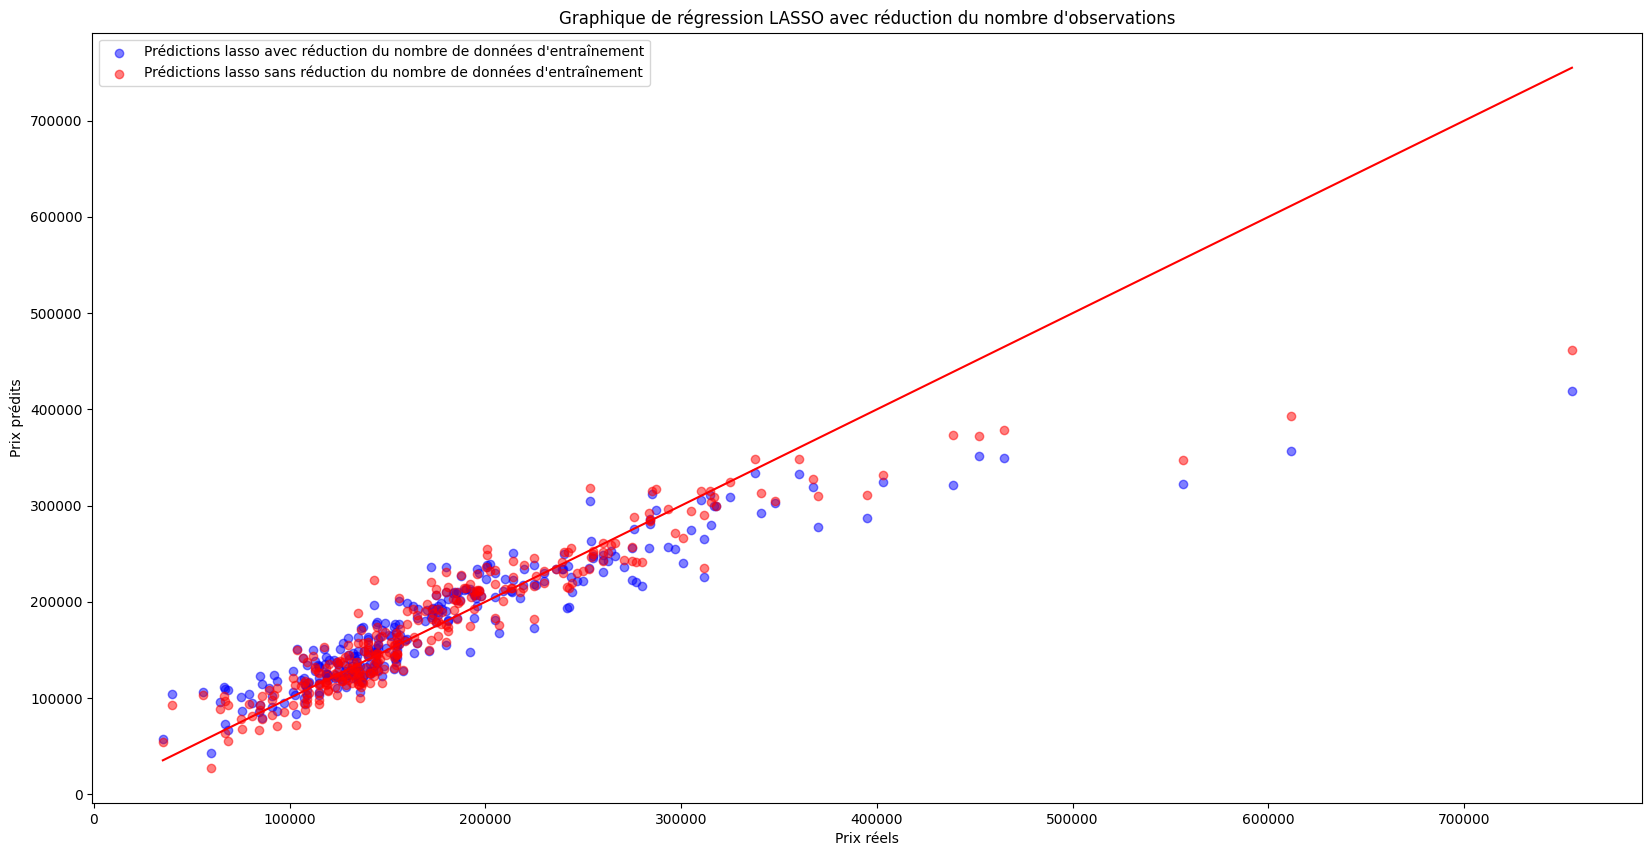

In [30]:
alphas=np.logspace(0, 5, 100)
model_lasso_reduit = LassoCV(alphas=alphas, cv=5, max_iter=10000) #cv=5 pour une 5-fold cross validation
model_lasso_reduit.fit(X_train_standard_reduit, y_reduit)
alpha_optimal= model_lasso_reduit.alpha_
print("Alpha optimal : ", alpha_optimal)

y_pred_lasso_reduit = model_lasso_reduit.predict(X_test_standard)
y_pred_train_lasso_reduit = model_lasso_reduit.predict(X_train_standard_reduit)
mae_test_lasso_reduit = np.mean(np.abs(y_pred_lasso_reduit-y_test))
mae_train_lasso_reduit=np.mean(np.abs(y_reduit - y_pred_train_lasso_reduit))
gap_lasso_reduit= mae_test_lasso_reduit- mae_train_lasso_reduit
s1=np.sum((y_pred_lasso_reduit-y_test)**2)
s2=np.sum((y_test - np.mean(y_test))**2)
score_lasso_reduit=1-s1/s2


print()
print("MAE test LASSO avec réduction : ",mae_test_lasso_reduit)
print("MAE test LASSO sans réduction : ",mae_test_lasso)
print()
print("Gap de généralisation LASSO avec réduction: ",gap_lasso_reduit)
print("Gap de généralisation LASSO sans réduction: ",gap_lasso)
print()
print()
print("MAE train LASSO avec réduction :",mae_train_lasso_reduit)
print("MAE train LASSO sans réduction :",mae_train_lasso)
print()
print("Score R2 LASSO avec réduction:",score_lasso_reduit)
print("Score R2 LASSO sans réduction:",score_lasso)



plt.figure(figsize=(20, 10))
plt.scatter(y_test, y_pred_lasso_reduit, color="blue",alpha=0.5,label="Prédictions lasso avec réduction du nombre de données d'entraînement")
plt.scatter(y_test, y_pred_lasso, color="red",alpha=0.5,label="Prédictions lasso sans réduction du nombre de données d'entraînement")
ligne=[np.min(y_test),np.max(y_test)]
plt.plot(ligne,ligne,color="red",alpha=1) #ligne de perfection, si un point est parfaitement sur la ligne, c'est que le prix prédit est exact
plt.title("Graphique de régression LASSO avec réduction du nombre d'observations")
plt.xlabel("Prix réels")
plt.ylabel("Prix prédits")  
plt.legend()


On peut voir que lorsque la taille du jeu d'entraînement est réduite, le risque que le modèle interprète du bruit aléatoire comme une règle générale augmente. Au lieu de sur-réagir comme le fait le MCO, le Lasso utilise sa pénalité pour annuler les variables non essentielles (coefficients à 0). En simplifiant le modèle, il réduit la variance et stabilise les coefficients restants, ce qui le maintient bien plus proche de la réalité (erreur de généralisation plus faible).

__c) Analyse des variables qui influencent le plus les prix et conlusion__

A priori, en termes de performances prédictives, il n'y a pas une grande différence entre une ACP suivie d'une méthode des moindres carrés, et une régularisation LASSO. Toutefois, la grande différence se fait au niveau de l'interprétation des résultats. Désormais, on peut analyser les coefficients qui influencent le plus les prix des maisons : 

In [36]:
coeffs = pd.Series(model_lasso.coef_, index=X_train.columns )
coeffs_tri = coeffs.sort_values()

coeffs_non_nuls = coeffs[coeffs != 0]
print("Nombre de variables conservées par le LASSO :", len(coeffs_non_nuls)," sur ",len(coeffs))
print()
print("Top 10 des variables qui influencent le plus les prix positivement")
print(coeffs_tri.tail(10)[::-1])
print("\n")
print("Top 10 des variables qui influencent le plus les prix négativement ")
print(coeffs_tri.head(10))

Nombre de variables conservées par le LASSO : 28  sur  77

Top 10 des variables qui influencent le plus les prix positivement
Surface habitable     22274.615029
Neighborhood          16611.318496
Qualité globale       15848.317277
Qualité cuisine        6095.952669
Places garage          5847.299202
BsmtExposure           4841.857669
Qualité extérieure     4214.043790
BsmtFinSF1             3605.792541
SaleType               3190.570177
BsmtFullBath           3117.819323
dtype: float64


Top 10 des variables qui influencent le plus les prix négativement 
MSSubClass             -6337.762296
Forme du terrain_IR3    -977.039546
BldgType_Twnhs          -181.357051
LotFrontage               -0.000000
BsmtCond                  -0.000000
ExterCond                  0.000000
Année construction         0.000000
Année rénovation           0.000000
FullBath                   0.000000
HalfBath                   0.000000
dtype: float64


On peut voir que LASSO a supprimé beaucoup de variables (28 restantes). Par exemple, l'année de construction est très corrélée à la qualité globale, donc Lasso a choisi de donner tout le poids à la Qualité (15 848) et d'annuler l'année pour éviter la redondance. C'est là toute la puissance de LASSO : on a réussi a simplifié le modèle, tout en le gardant très précis en termes de performances prédictives. 

__3) Tableaux comparatifs finaux__

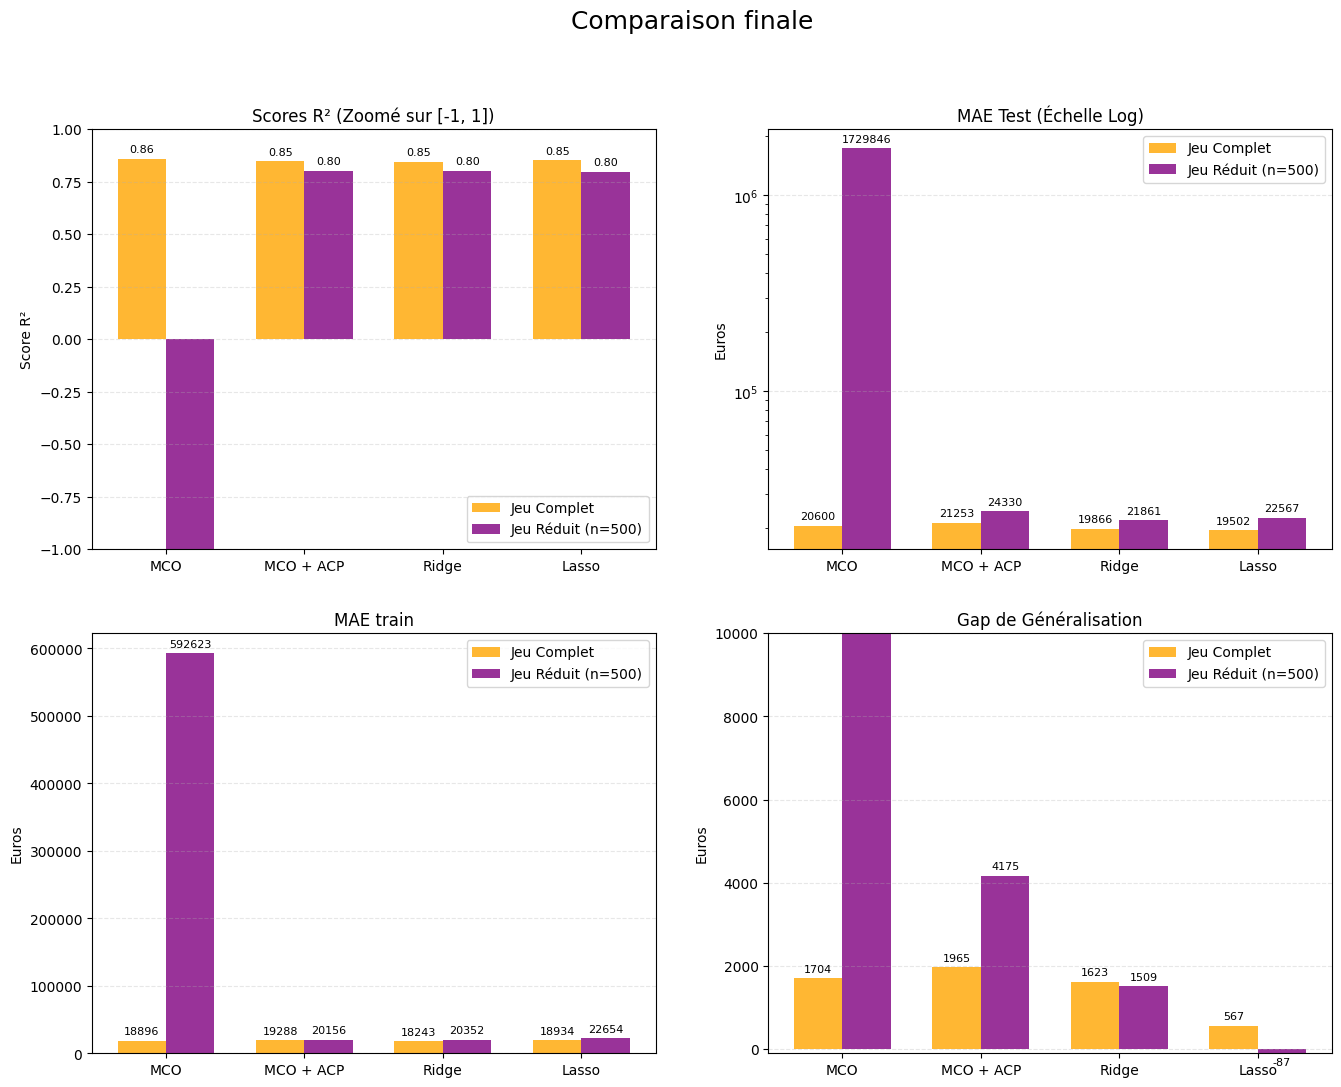

In [37]:

methodes = ['MCO', 'MCO + ACP', 'Ridge', 'Lasso']

scores_complet = [score_mco, score_acp, score_ridge, score_lasso]
scores_reduit  = [score_mco_reduit, score_acp_reduit, score_ridge_reduit, score_lasso_reduit]

mae_test_complet = [mae_test_mco, mae_test_acp, mae_test_ridge, mae_test_lasso]
mae_test_reduit  = [mae_test_mco_reduit, mae_test_acp_reduit, mae_test_ridge_reduit, mae_test_lasso_reduit]

mae_train_complet = [mae_train_mco, mae_train_acp, mae_train_ridge, mae_train_lasso]
mae_train_reduit  = [mae_train_mco_reduit, mae_train_acp_reduit, mae_train_ridge_reduit, mae_train_lasso_reduit]

gap_complet = [gap_mco, gap_acp, gap_ridge, gap_lasso]
gap_reduit  = [gap_mco_reduit, gap_acp_reduit, gap_ridge_reduit, gap_lasso_reduit]

#Histogrammes
#On fait 4 histogrammes (score, erreur de generalisation, erreur d'approximation, erreur de test). On compare a chaque fois les methodes avant ou après réduction du nb d'observations

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
x = np.arange(len(methodes))
width = 0.35
c1="orange"
c2="purple"

def tracer_barres(ax, complet, reduit, titre, ylabel, log_scale=False, y_limit=None):
    bar1=ax.bar(x - width/2, complet, width, label='Jeu Complet', color=c1, alpha=0.8)
    bar2=ax.bar(x + width/2, reduit, width, label='Jeu Réduit (n=500)', color=c2, alpha=0.8)
    ax.set_title(titre)
    ax.set_xticks(x)
    ax.set_xticklabels(methodes)
    ax.set_ylabel(ylabel)
    if log_scale:
        ax.set_yscale('log') 
    if y_limit:
        ax.set_ylim(y_limit) #empeche le score r2 de descendre à -500 000
    
    format_label = '%.2f' if 'Score' in titre else '%.0f'
    
    ax.bar_label(bar1, padding=3, fmt=format_label, fontsize=8)
    ax.bar_label(bar2, padding=3, fmt=format_label, fontsize=8)

    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.legend()
    

    
    

plt.suptitle("Comparaison finale", fontsize=18, y=0.98)
tracer_barres(axes[0, 0], scores_complet, scores_reduit, 'Scores R² (Zoomé sur [-1, 1])', 'Score R²', y_limit=(-1, 1))  #On limite entre -1 et 1 pour voir bien voir
tracer_barres(axes[0, 1], mae_test_complet, mae_test_reduit, 'MAE Test (Échelle Log)', 'Euros', log_scale=True)
tracer_barres(axes[1, 0], mae_train_complet, mae_train_reduit, "MAE train", 'Euros')
tracer_barres(axes[1, 1], gap_complet,gap_reduit, "Gap de Généralisation", 'Euros',y_limit=(-100, 10000))


### V. CONCLUSION

Pour rappel, l'objectif de ce projet était d'évaluer dans quelle mesure l'ajout du pénalité (Ridge ou LASSO) permet d'améliorer une méthode des moindres carrés ordinaires dans la prédiction des prix de l'immobilier. 

Dans un premier temps, on a pu remarquer que face à la multicolinéarité des données, la méthode des moindres carrés ordinaires échoue brutalement lorsque l'on réduit la taille des données d'entraînement. Avec peu de données et beaucoup de variables de bruit, le modèle apprend par coeur le bruit (overfitting), ce qui provoque une erreur de généralisation importante. Résultat, le modèle prédit moins bien que la simple moyenne des prix. Cela se traduit par un gap de généralisation élevé : le modèle accorde des coefficients disproportionnés à des variables de bruit. Par conséquent, le modèle n'est plus capable de généraliser : il a appris par coeur les spécificités du jeu d'entraînement au lieu de saisir les tendances générales
: l'erreur de test explose, le score R2 devient négatif ce qui signifie qu'il prédit moins bien qu'une simple moyenne des prix. 

L'ACP combinée avec la méthode des moindres carrés offre une alternative intéressante au sur-apprentissage. En compressant l'information et en ne gardant que les composantes principales, l'ACP élimine une grande partie du bruit. De plus, chacune des composantes principales étant indépendante des autres, l'ACP nous permet de mieux gérer la multicolinéarité des données. On observe une nette amélioration par rapport au MCO seul, même si les performances restent légèrement en desous de celles de Ridge et Lasso dans notre cas. Cependant, un problème subsistait : l'interprétation des coefficients et des variables qui influencent le plus les prix. En projetant nos données sur de nouveaux axes, l'acp nous empêche d'analyser ces variables. 

Enfin, nos analyses ont montré que les modèles Ridge et Lasso s'imposent comme les solutions les plus performantes et stables. Ils maintiennent un score $R^2$ élevé (environ 0.85 sur le jeu complet, 0.80 sur le jeu réduit). En effet, ces modèles ignorent naturellement le bruit en leur accordant des coefficients très faibles pour se concentrer sur les variables réellement prédictives (Surface, Qualité, etc.). Lasso se distingue d'ailleurs par sa capacité à annuler totalement les variables inutiles (coefficients nuls) ce qui rend le modèle beaucoup plus simple. De plus, contrairement à l'ACP+MCO, on a pu analyser quels facteurs influencent le plus les prix. Si certaines variables comme la surface ont un impact positif évident, d'autres comme MSSubClass ou terrainIR3 affichent un coefficient négatif après régularisation. Cela ne signifie pas forcément qu'elles ont moins d'importance, mais qu'elles agissent comme un correcteur : à caractéristiques égales, certains types de construction ou de formes de terrain (IR3) dévaluent le bien par rapport au standard du marché.


Le graphique des erreurs MAE (erreurs sur le train) montre que le MCO a une erreur faible sur le jeu complet. Cependant, une faible erreur MAE sur le train cache souvent une variance élevée (compromis biais-variance). Les modèles Ridge et LASSO acceptent une erreur MAE plus élevée sur le train (plus de biais) pour obtenir une erreur plus faible sur le test (moins de variance).

En résumé, on peut dire que pour ce projet de prédiction immobilière, les méthodes Ridge et Lasso sont préférables car elles offrent le meilleur équilibre entre précision, de généralisation et d'interprétation. C'est exactement le résultat auxquel ont s'attendait au vu de la théorie évoquée lors de l'introduction.